Generating visualizations for DEFACTO_256


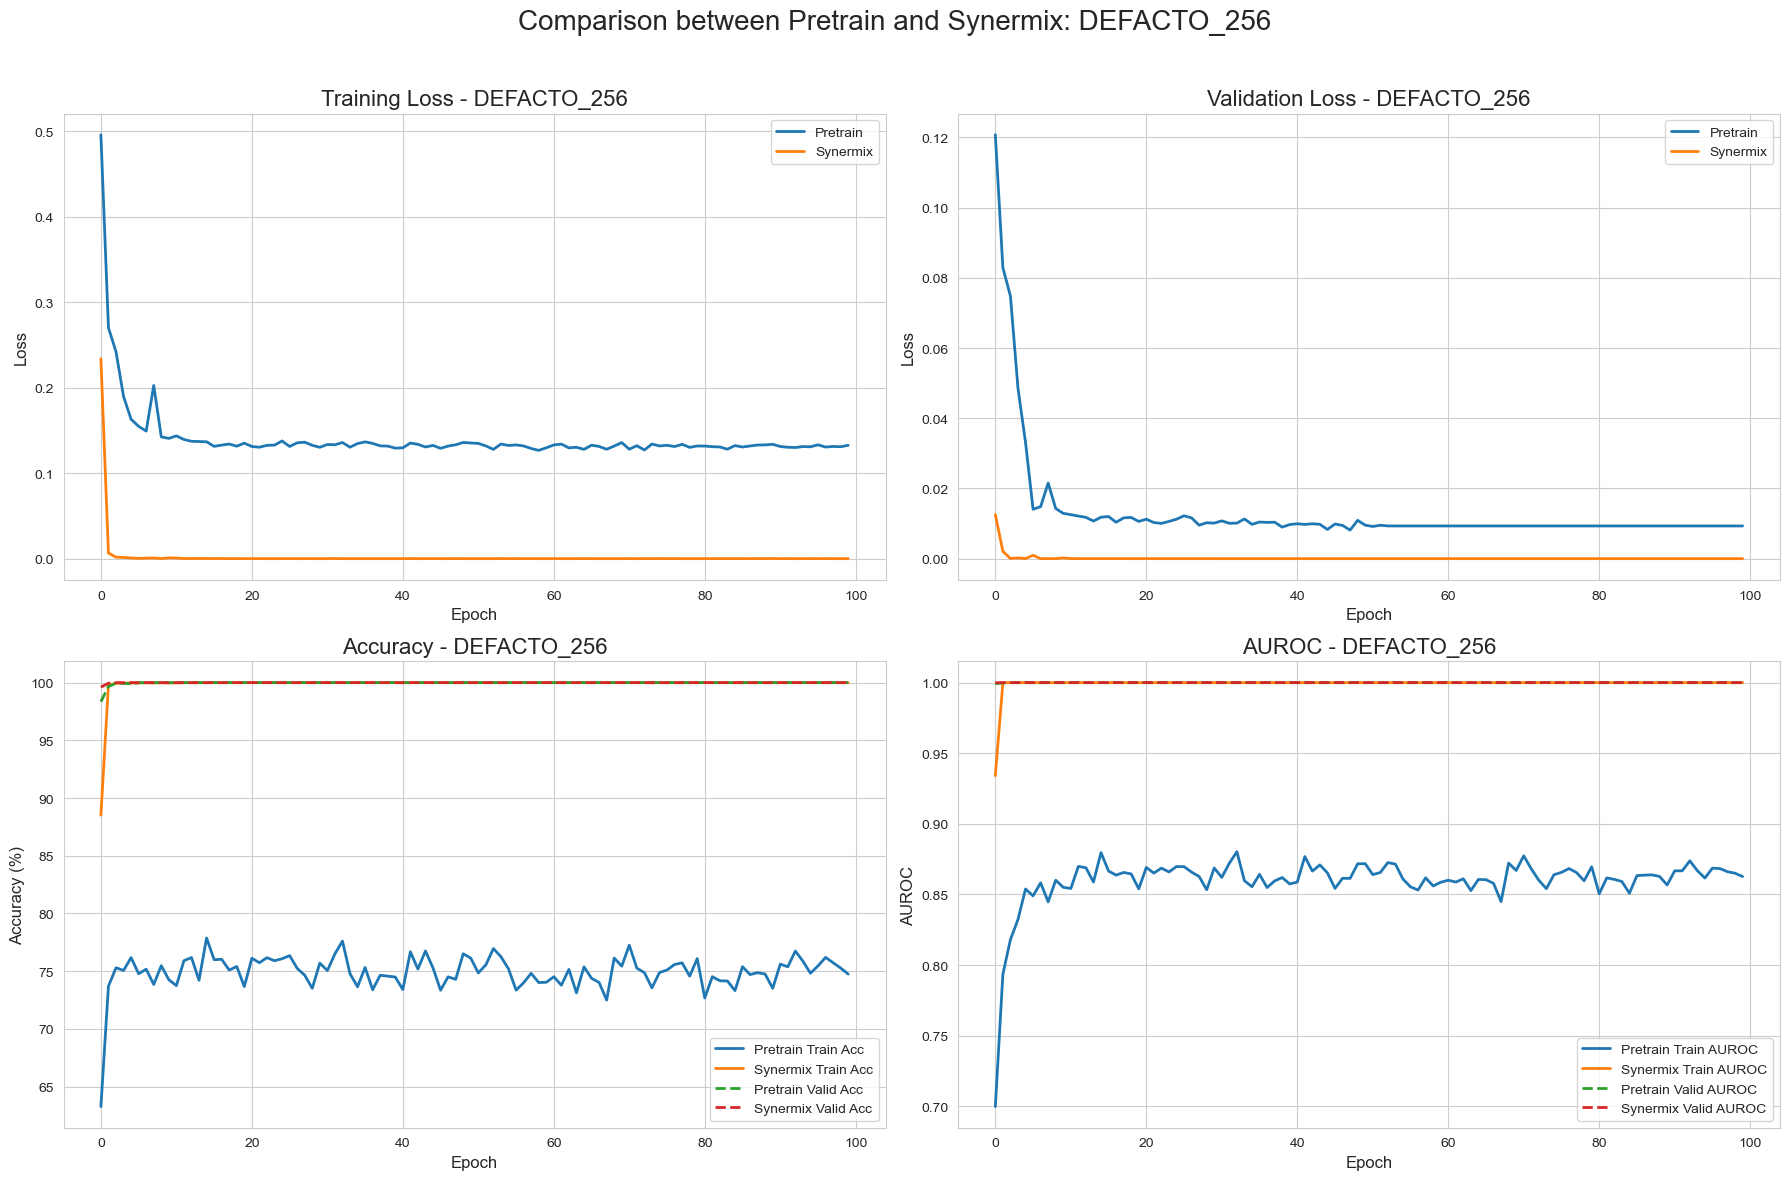

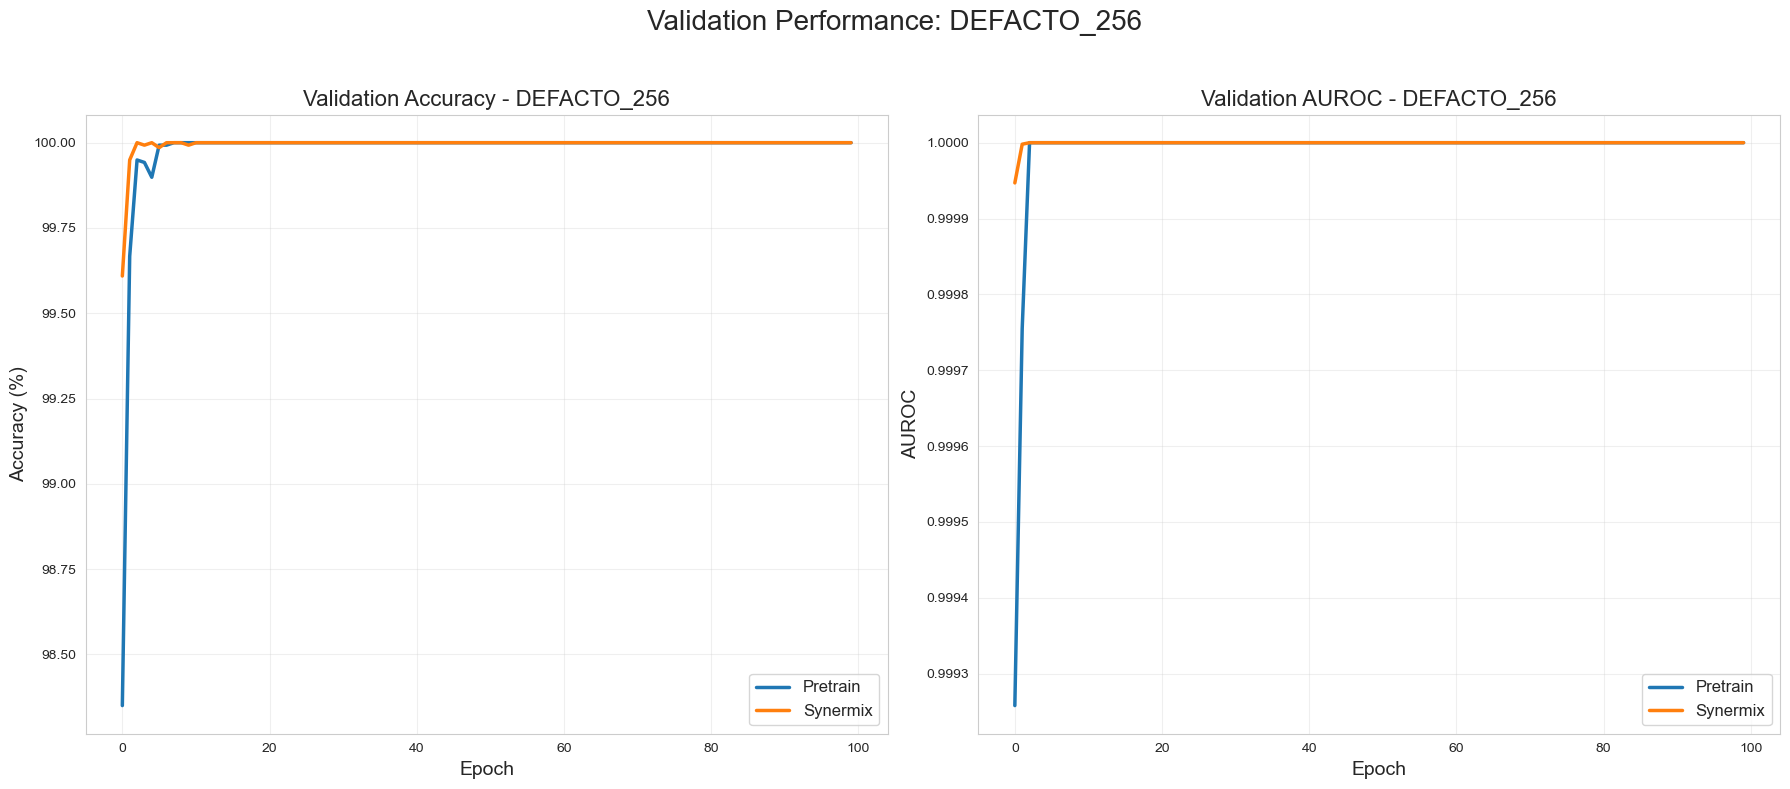

Generating visualizations for FLUX1_256


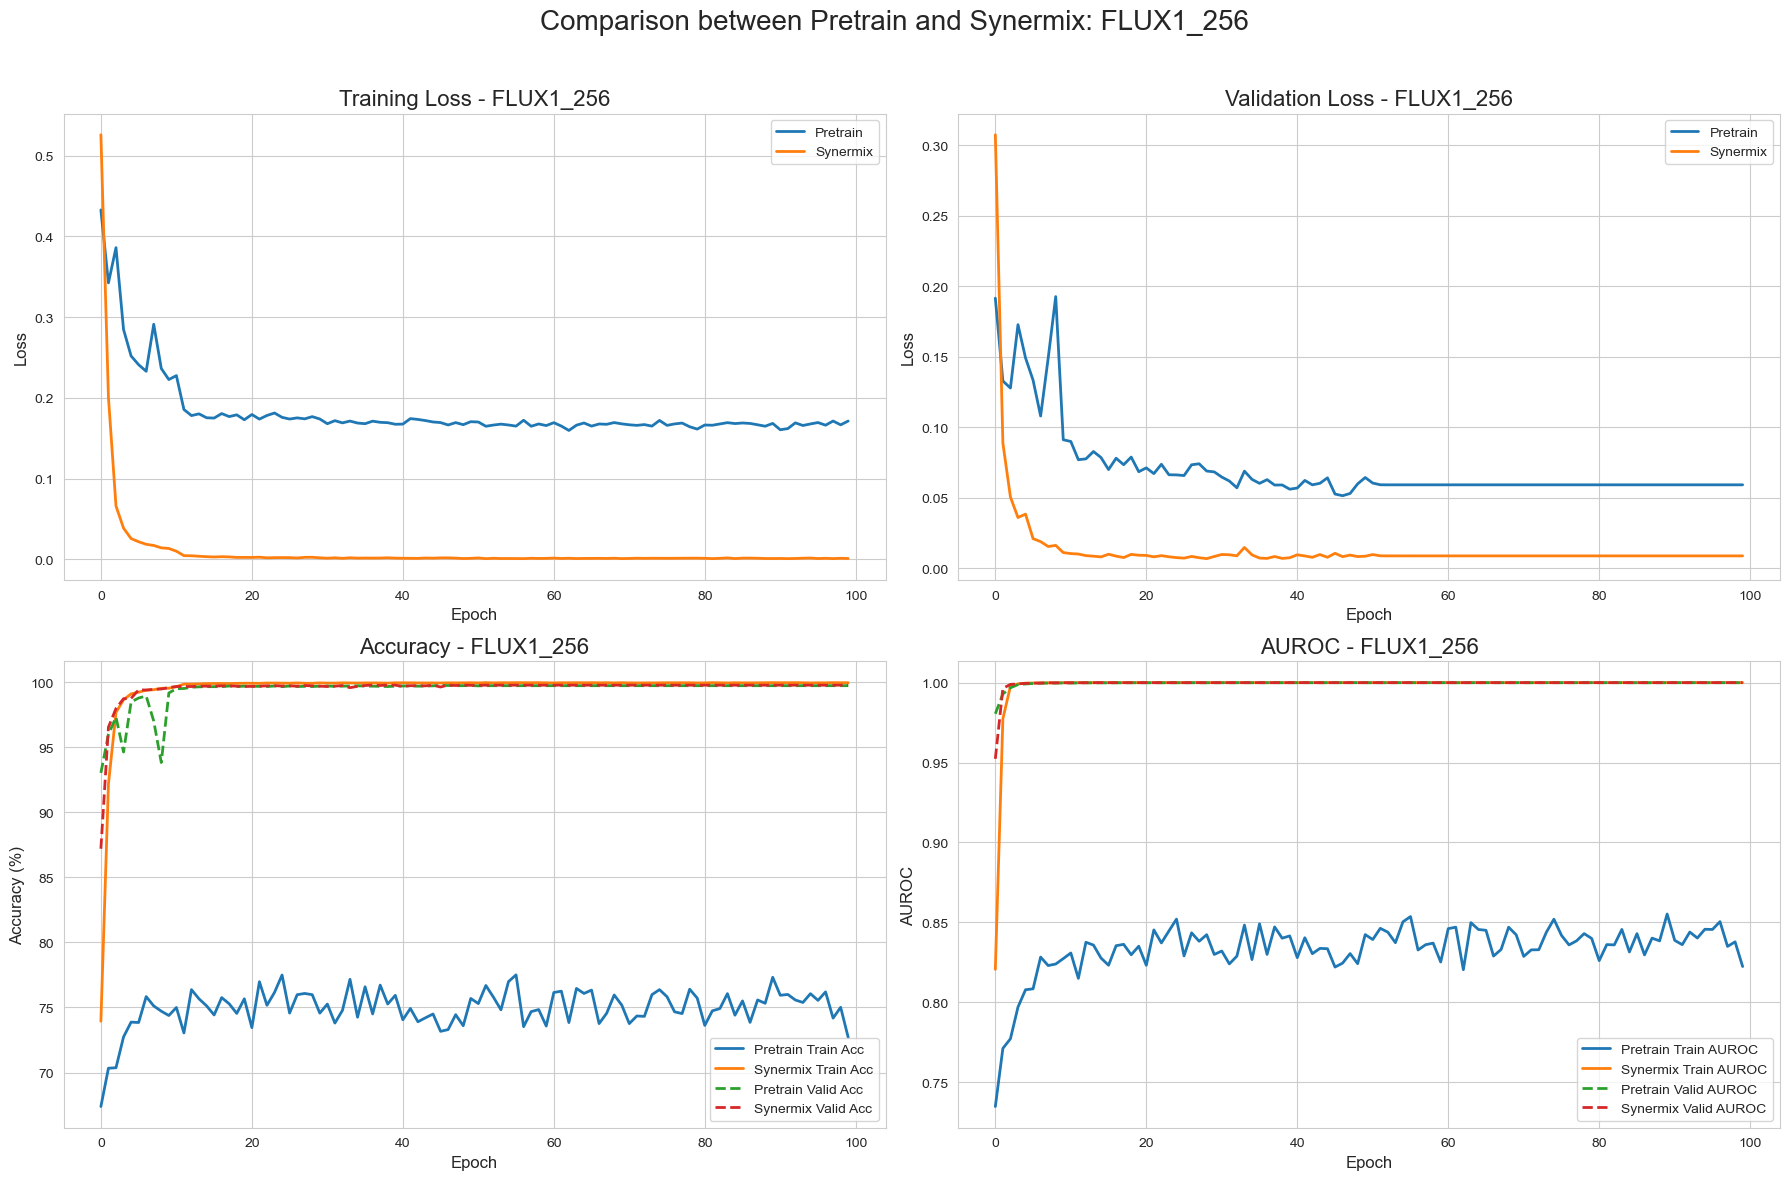

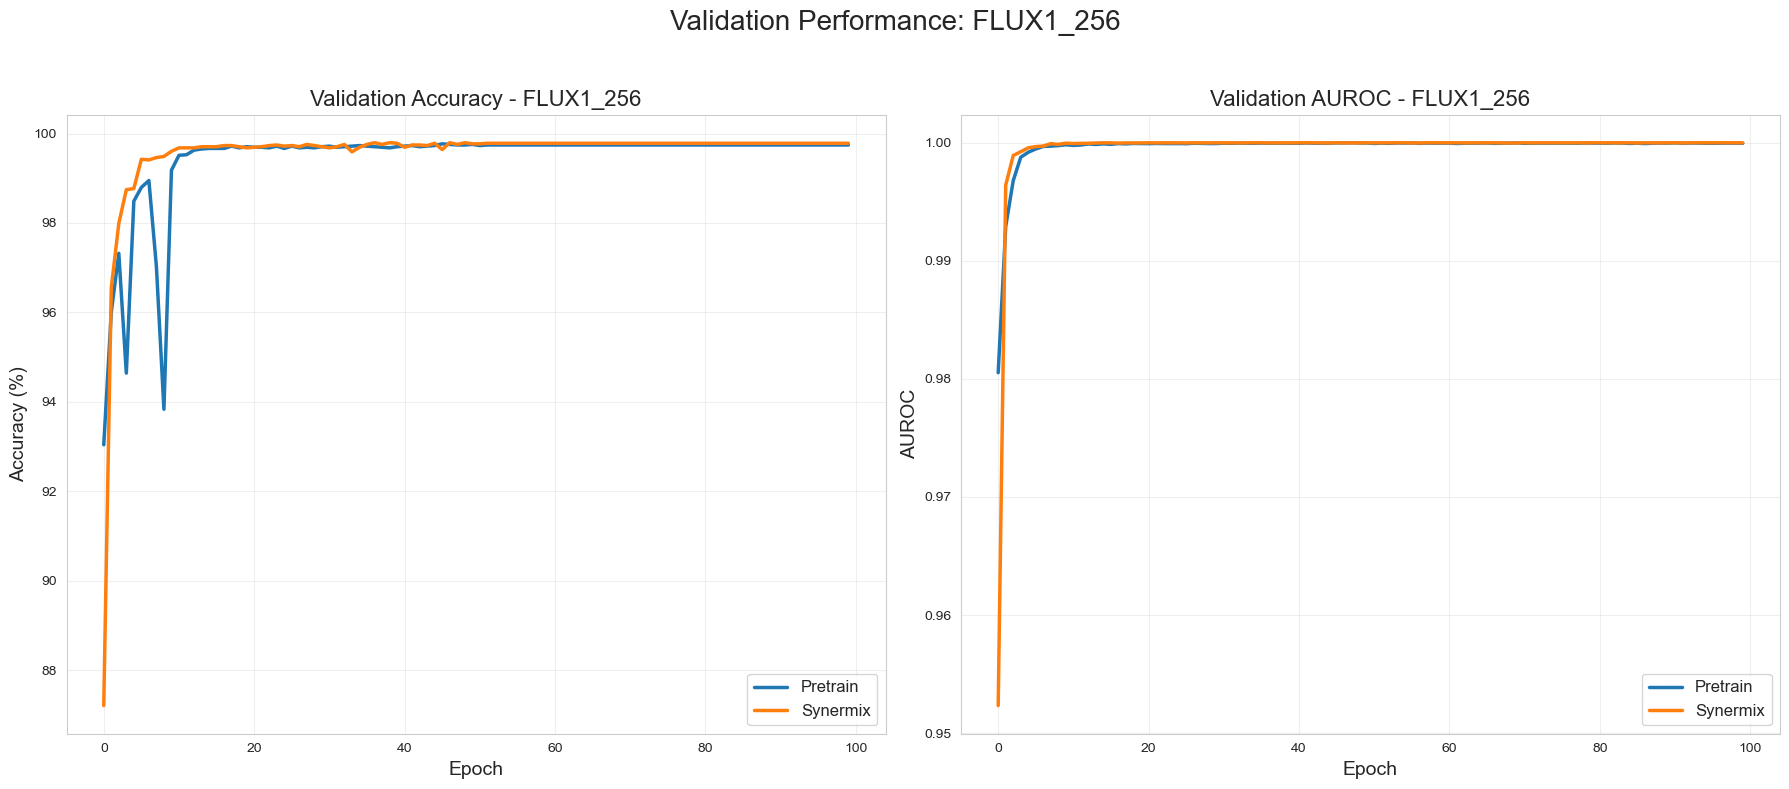

Generating visualizations for StableDiffusion_256


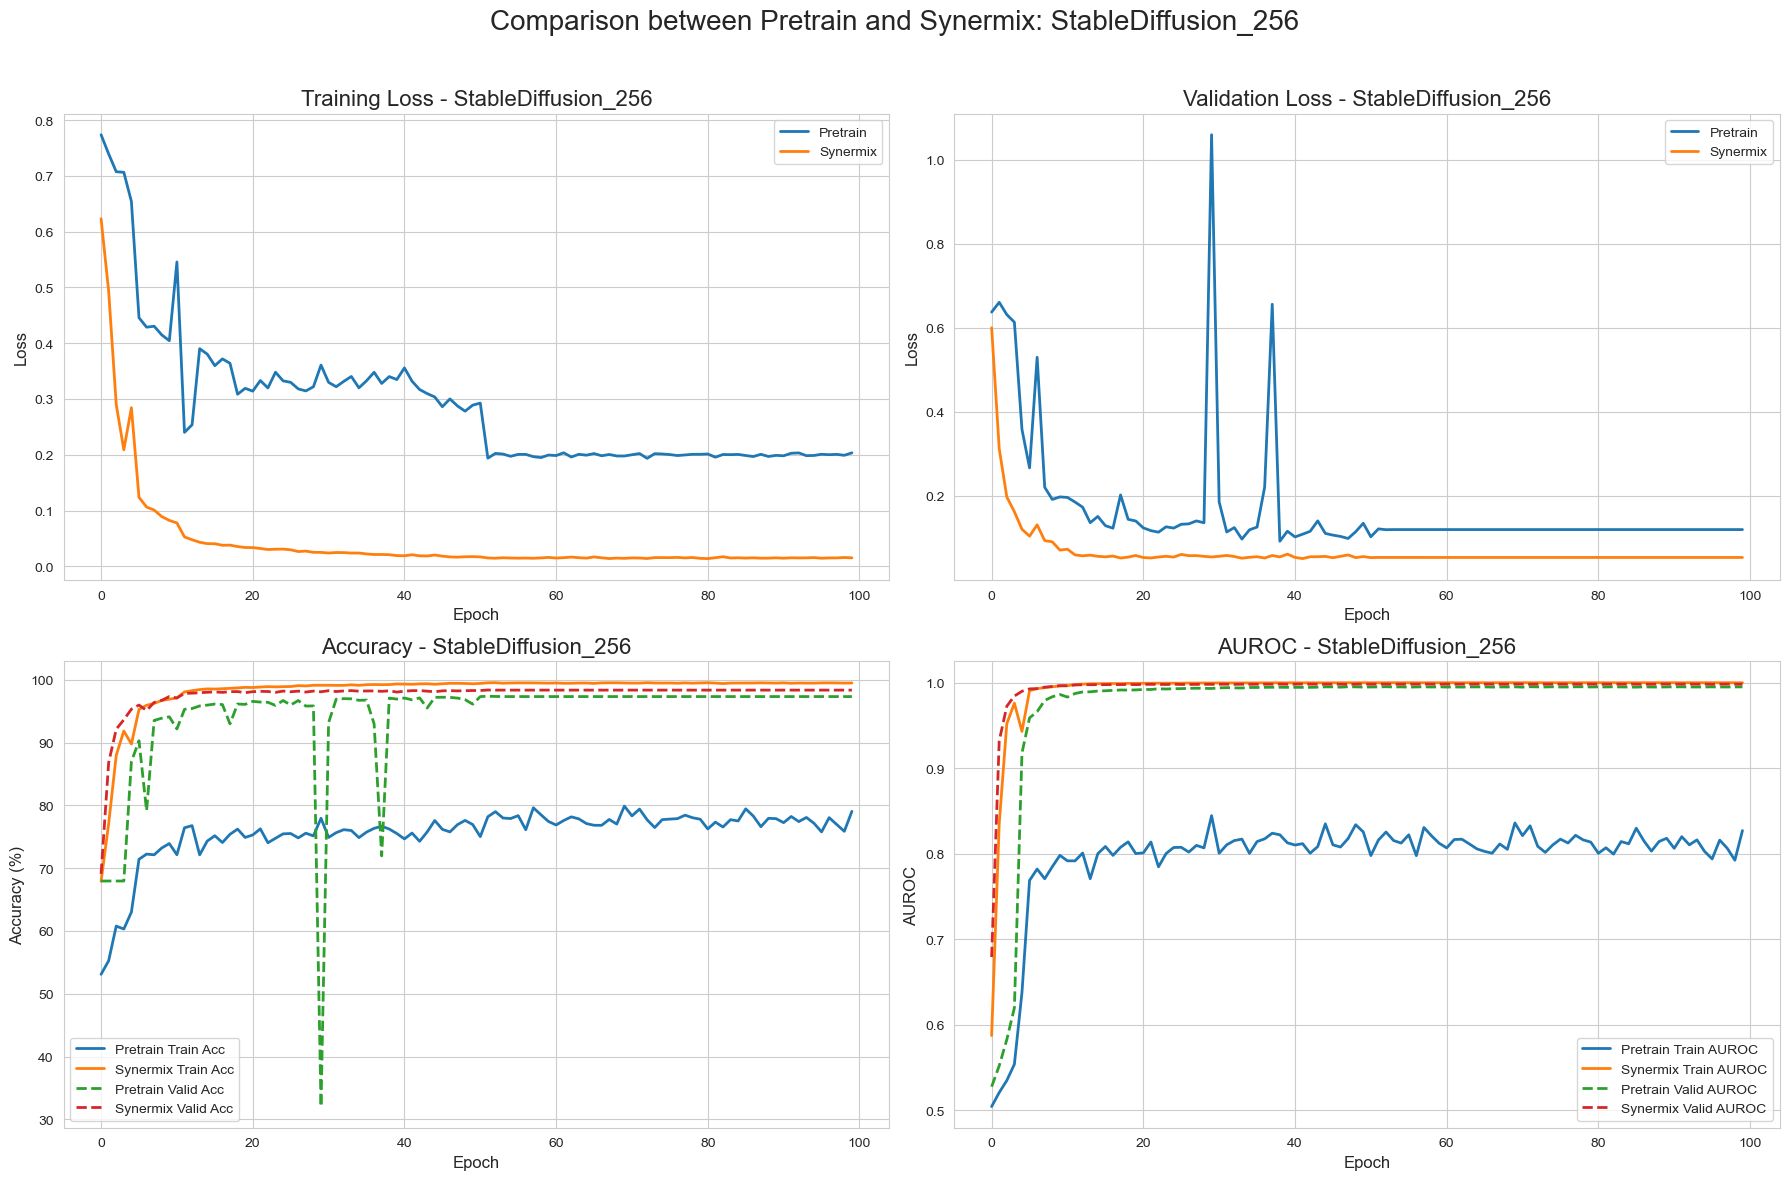

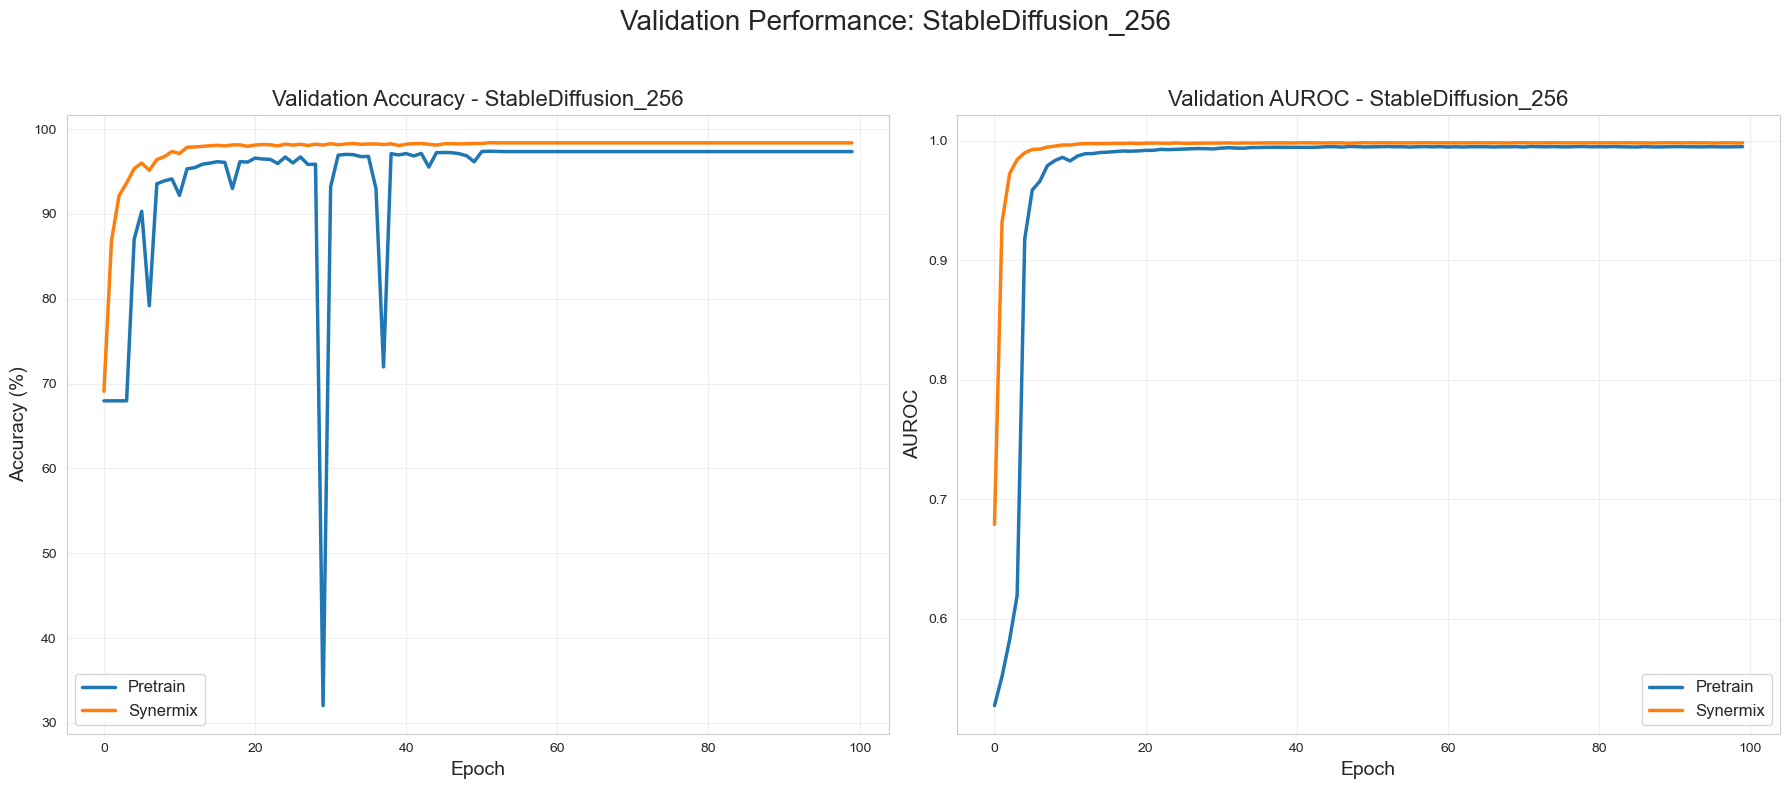

Generating visualizations for StyleGAN2_256


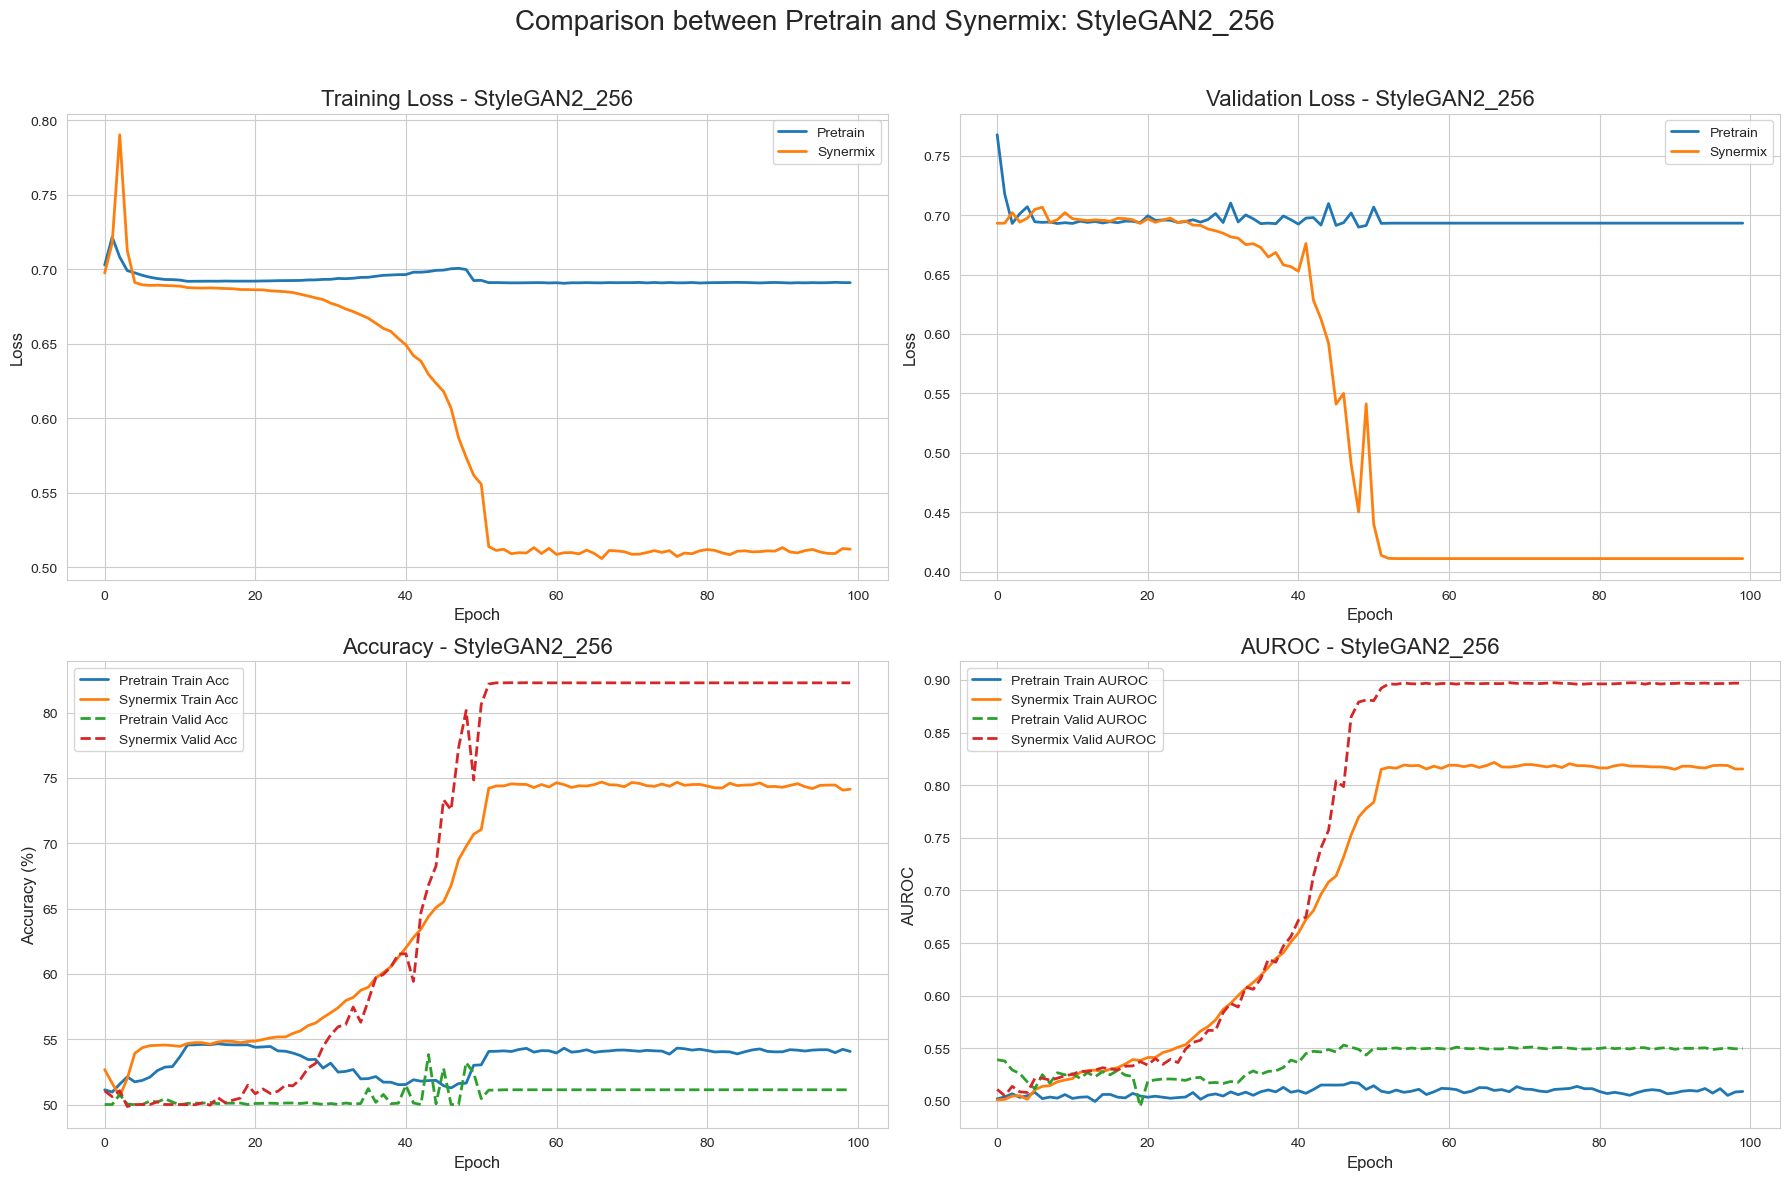

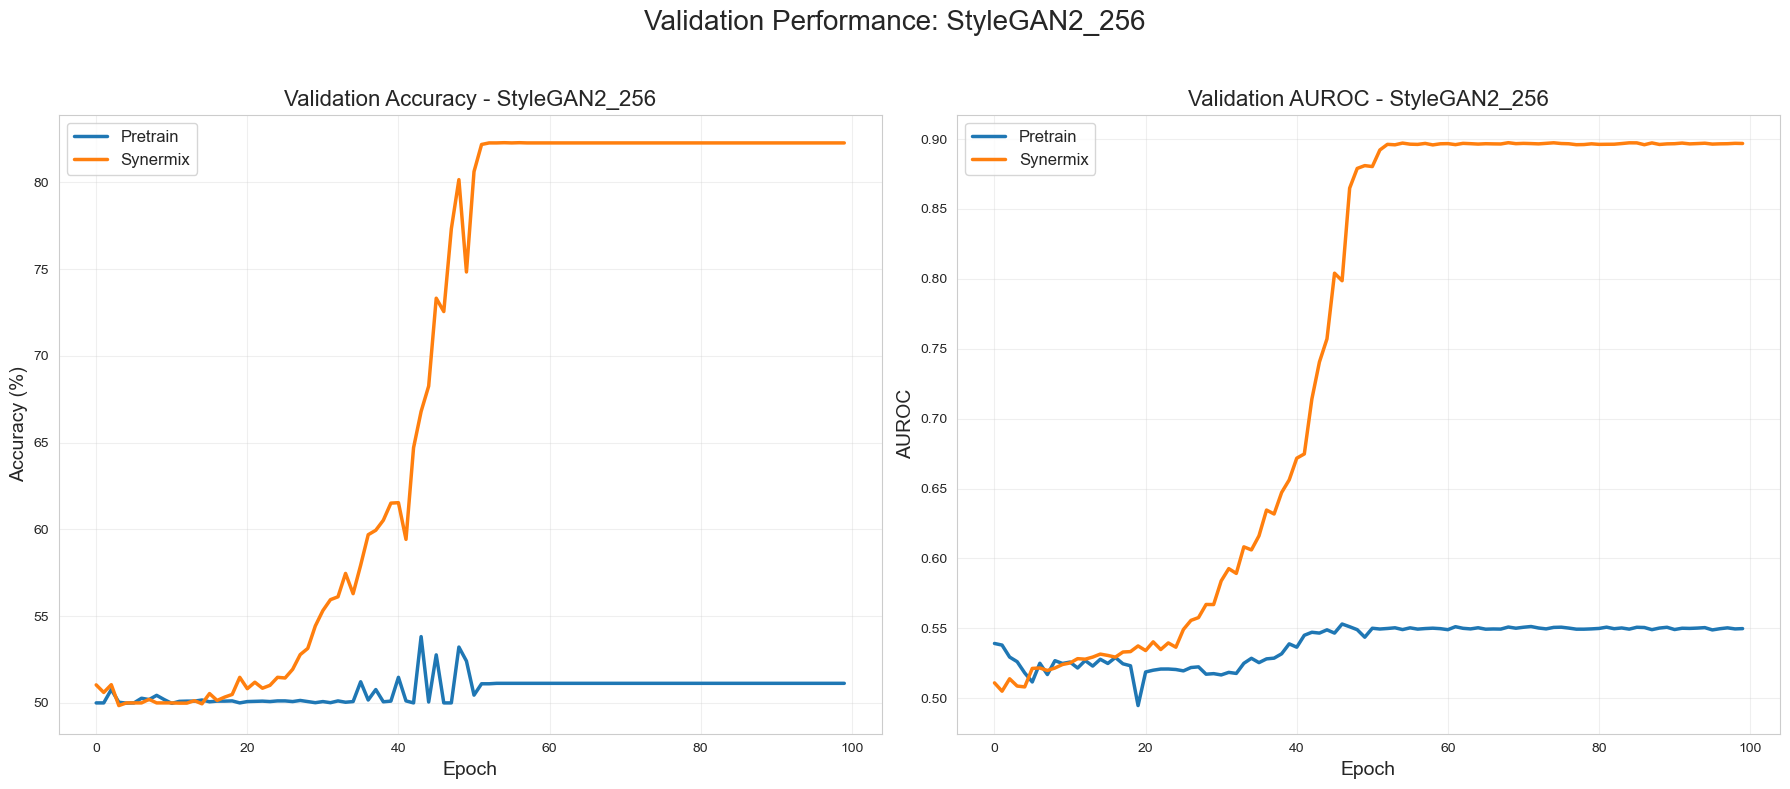

Generating visualizations for StyleGAN_256


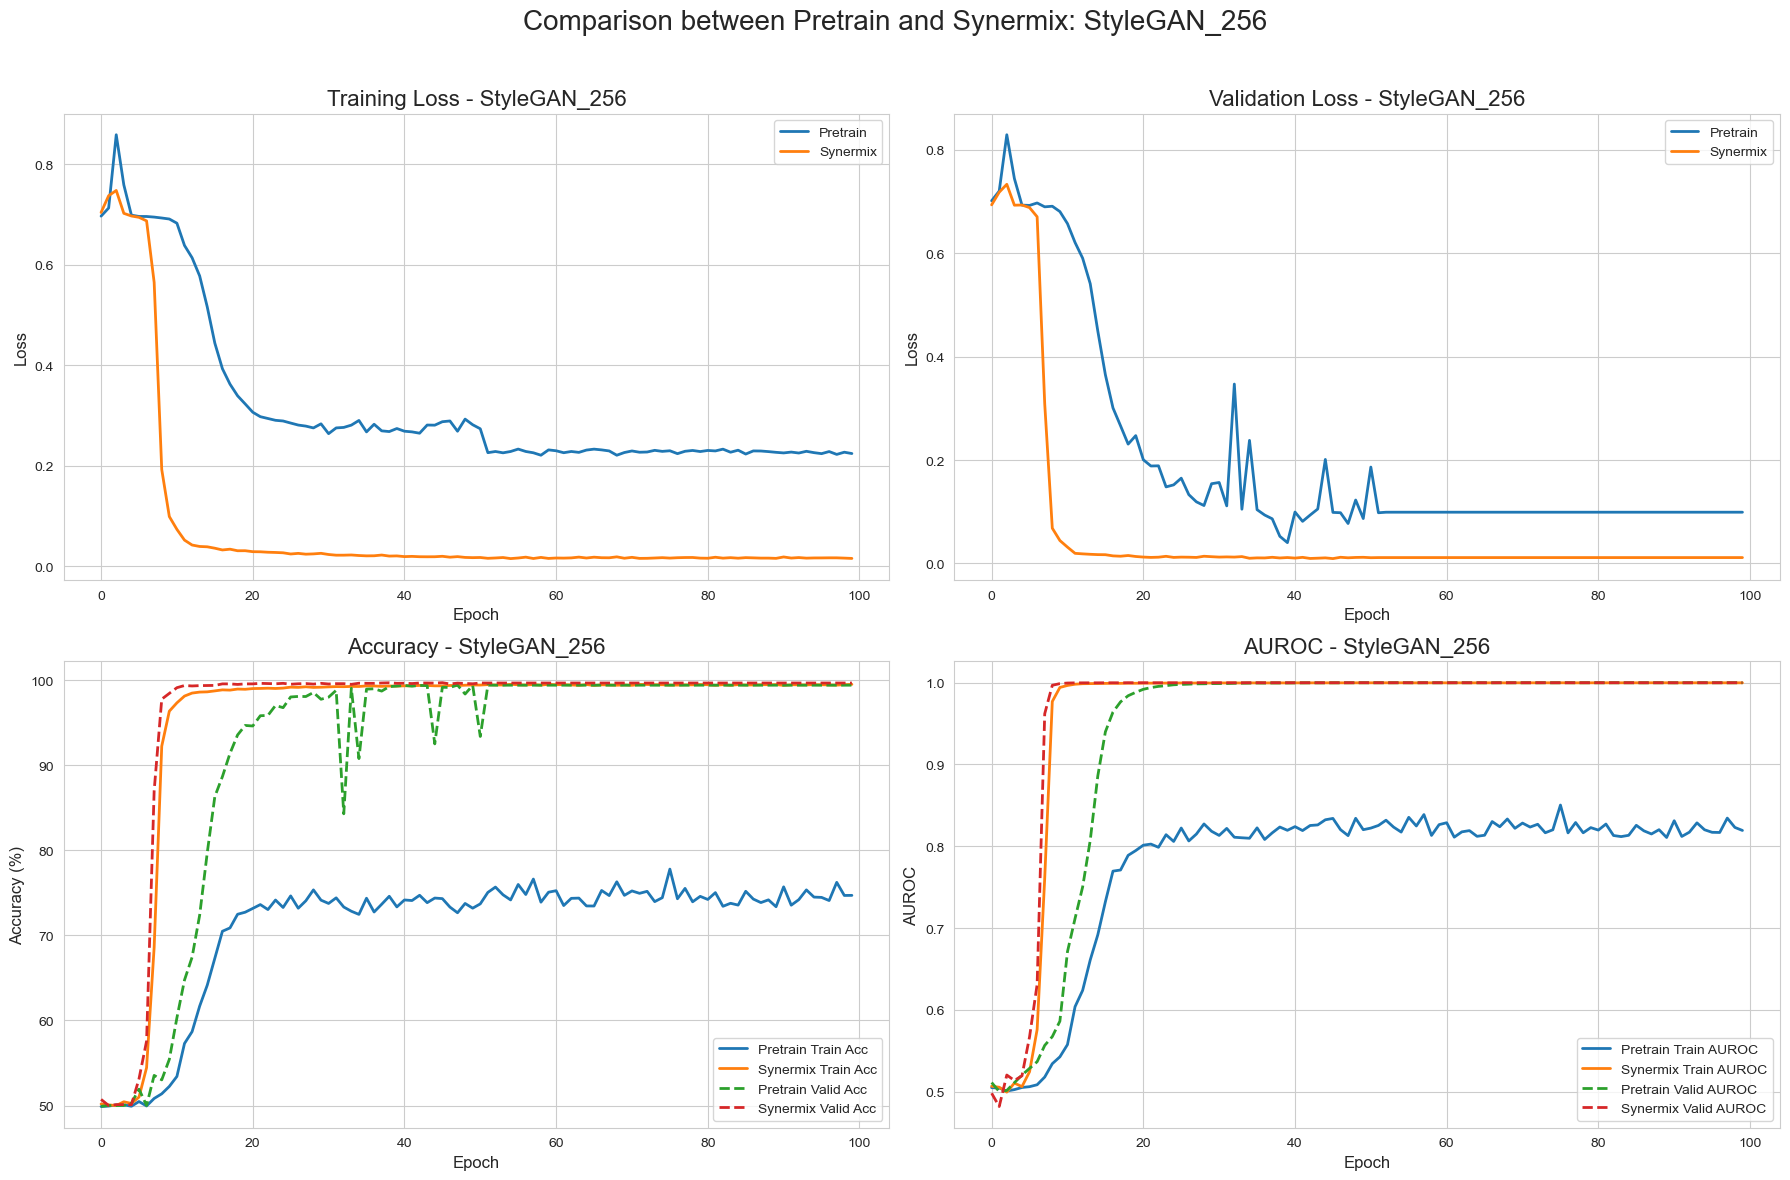

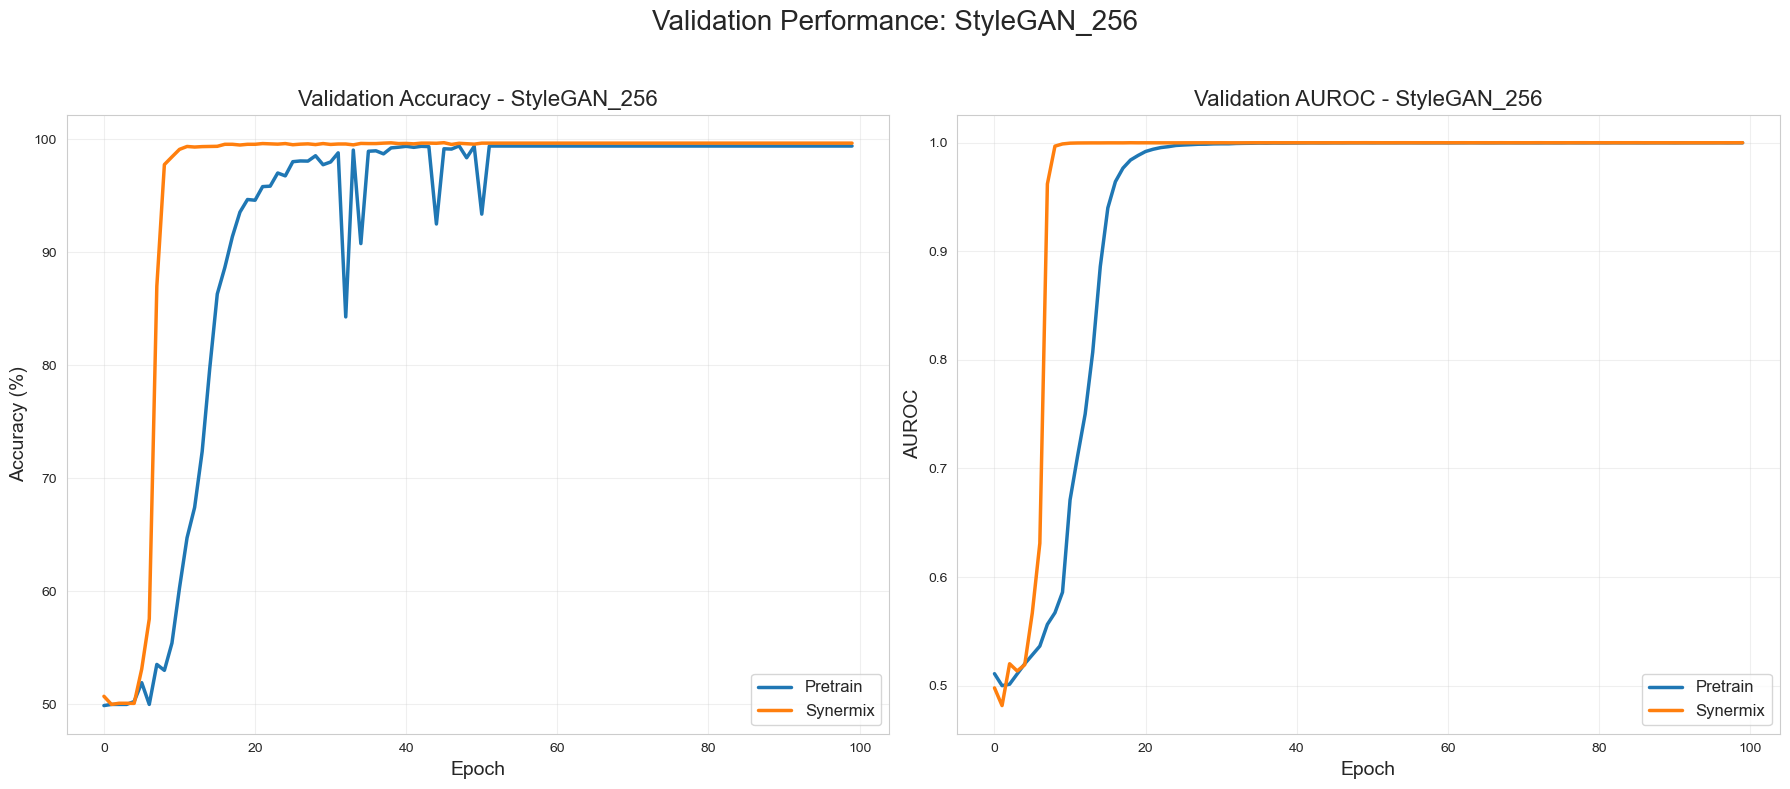

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 12)

# Define base path
base_path = Path('\\\\wsl.localhost\\Ubuntu\\home\\vincent\\Thesis-master\\logsv2')

# Model names
models = ['DEFACTO_256', 'FLUX1_256', 'StableDiffusion_256', 'StyleGAN2_256', 'StyleGAN_256']

# Function to load data for a model
def load_model_data(model_name):
    # Handle file name variations
    if model_name == 'FLUX1_256':
        pretrain_file = f"pretrain_FLUX1_log.txt"
        synermix_file = f"synermix_FLUX1_log.txt"
    elif model_name == 'StyleGAN_256':
        pretrain_file = f"pretrain_StyleGAN_log.txt"
        synermix_file = f"synermix_StyleGAN_log.txt"
    elif model_name == 'StableDiffusion_256':
        pretrain_file = f"pretrain_StableDiffusion_log.txt"
        synermix_file = f"synermix_StableDiffusion_log.txt"
    elif model_name == 'DEFACTO_256':
        pretrain_file = f"pretrain_DEFACTO_256_log.txt"
        synermix_file = f"synermix_DEFACTO_log.txt"
    else:  # StyleGAN2_256
        pretrain_file = f"pretrain_{model_name}.txt"
        synermix_file = f"synermix_{model_name}_log.txt"
    
    # Load data
    pretrain_path = base_path / 'base' / model_name / pretrain_file
    synermix_path = base_path / 'synermix' / model_name / synermix_file
    
    try:
        pretrain_df = pd.read_csv(pretrain_path, sep='\t')
        synermix_df = pd.read_csv(synermix_path, sep='\t')
        return pretrain_df, synermix_df
    except Exception as e:
        print(f"Error loading {model_name}: {e}")
        return None, None

# Create visualizations for each model
for model_name in models:
    pretrain_df, synermix_df = load_model_data(model_name)
    if pretrain_df is None or synermix_df is None:
        continue
        
    print(f"Generating visualizations for {model_name}")
    
    # Create a figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Plot Training Loss
    axes[0, 0].plot(pretrain_df['Train Loss'], label='Pretrain', linewidth=2)
    axes[0, 0].plot(synermix_df['Train Loss'], label='Synermix', linewidth=2)
    axes[0, 0].set_title(f'Training Loss - {model_name}', fontsize=16)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].legend()
    
    # Plot Validation Loss
    axes[0, 1].plot(pretrain_df['Valid Loss'], label='Pretrain', linewidth=2)
    axes[0, 1].plot(synermix_df['Valid Loss'], label='Synermix', linewidth=2)
    axes[0, 1].set_title(f'Validation Loss - {model_name}', fontsize=16)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Loss', fontsize=12)
    axes[0, 1].legend()
    
    # Plot Training & Validation Accuracy
    axes[1, 0].plot(pretrain_df['Train Acc.'], label='Pretrain Train Acc', linewidth=2)
    axes[1, 0].plot(synermix_df['Train Acc.'], label='Synermix Train Acc', linewidth=2)
    axes[1, 0].plot(pretrain_df['Valid Acc.'], label='Pretrain Valid Acc', linestyle='--', linewidth=2)
    axes[1, 0].plot(synermix_df['Valid Acc.'], label='Synermix Valid Acc', linestyle='--', linewidth=2)
    axes[1, 0].set_title(f'Accuracy - {model_name}', fontsize=16)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1, 0].legend()
    
    # Plot Training & Validation AUROC
    axes[1, 1].plot(pretrain_df['Train AUROC.'], label='Pretrain Train AUROC', linewidth=2)
    axes[1, 1].plot(synermix_df['Train AUROC.'], label='Synermix Train AUROC', linewidth=2)
    axes[1, 1].plot(pretrain_df['Valid AUROC.'], label='Pretrain Valid AUROC', linestyle='--', linewidth=2)
    axes[1, 1].plot(synermix_df['Valid AUROC.'], label='Synermix Valid AUROC', linestyle='--', linewidth=2)
    axes[1, 1].set_title(f'AUROC - {model_name}', fontsize=16)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('AUROC', fontsize=12)
    axes[1, 1].legend()
    
    # Add a main title
    fig.suptitle(f'Comparison between Pretrain and Synermix: {model_name}', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Create a focused comparison of validation metrics
    plt.figure(figsize=(18, 8))
    
    # Plot Validation Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(pretrain_df['Valid Acc.'], label='Pretrain', linewidth=2.5)
    plt.plot(synermix_df['Valid Acc.'], label='Synermix', linewidth=2.5)
    plt.title(f'Validation Accuracy - {model_name}', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Plot Validation AUROC
    plt.subplot(1, 2, 2)
    plt.plot(pretrain_df['Valid AUROC.'], label='Pretrain', linewidth=2.5)
    plt.plot(synermix_df['Valid AUROC.'], label='Synermix', linewidth=2.5)
    plt.title(f'Validation AUROC - {model_name}', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('AUROC', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.suptitle(f'Validation Performance: {model_name}', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Creating scatter plots for DEFACTO_256


<Figure size 2000x1500 with 0 Axes>

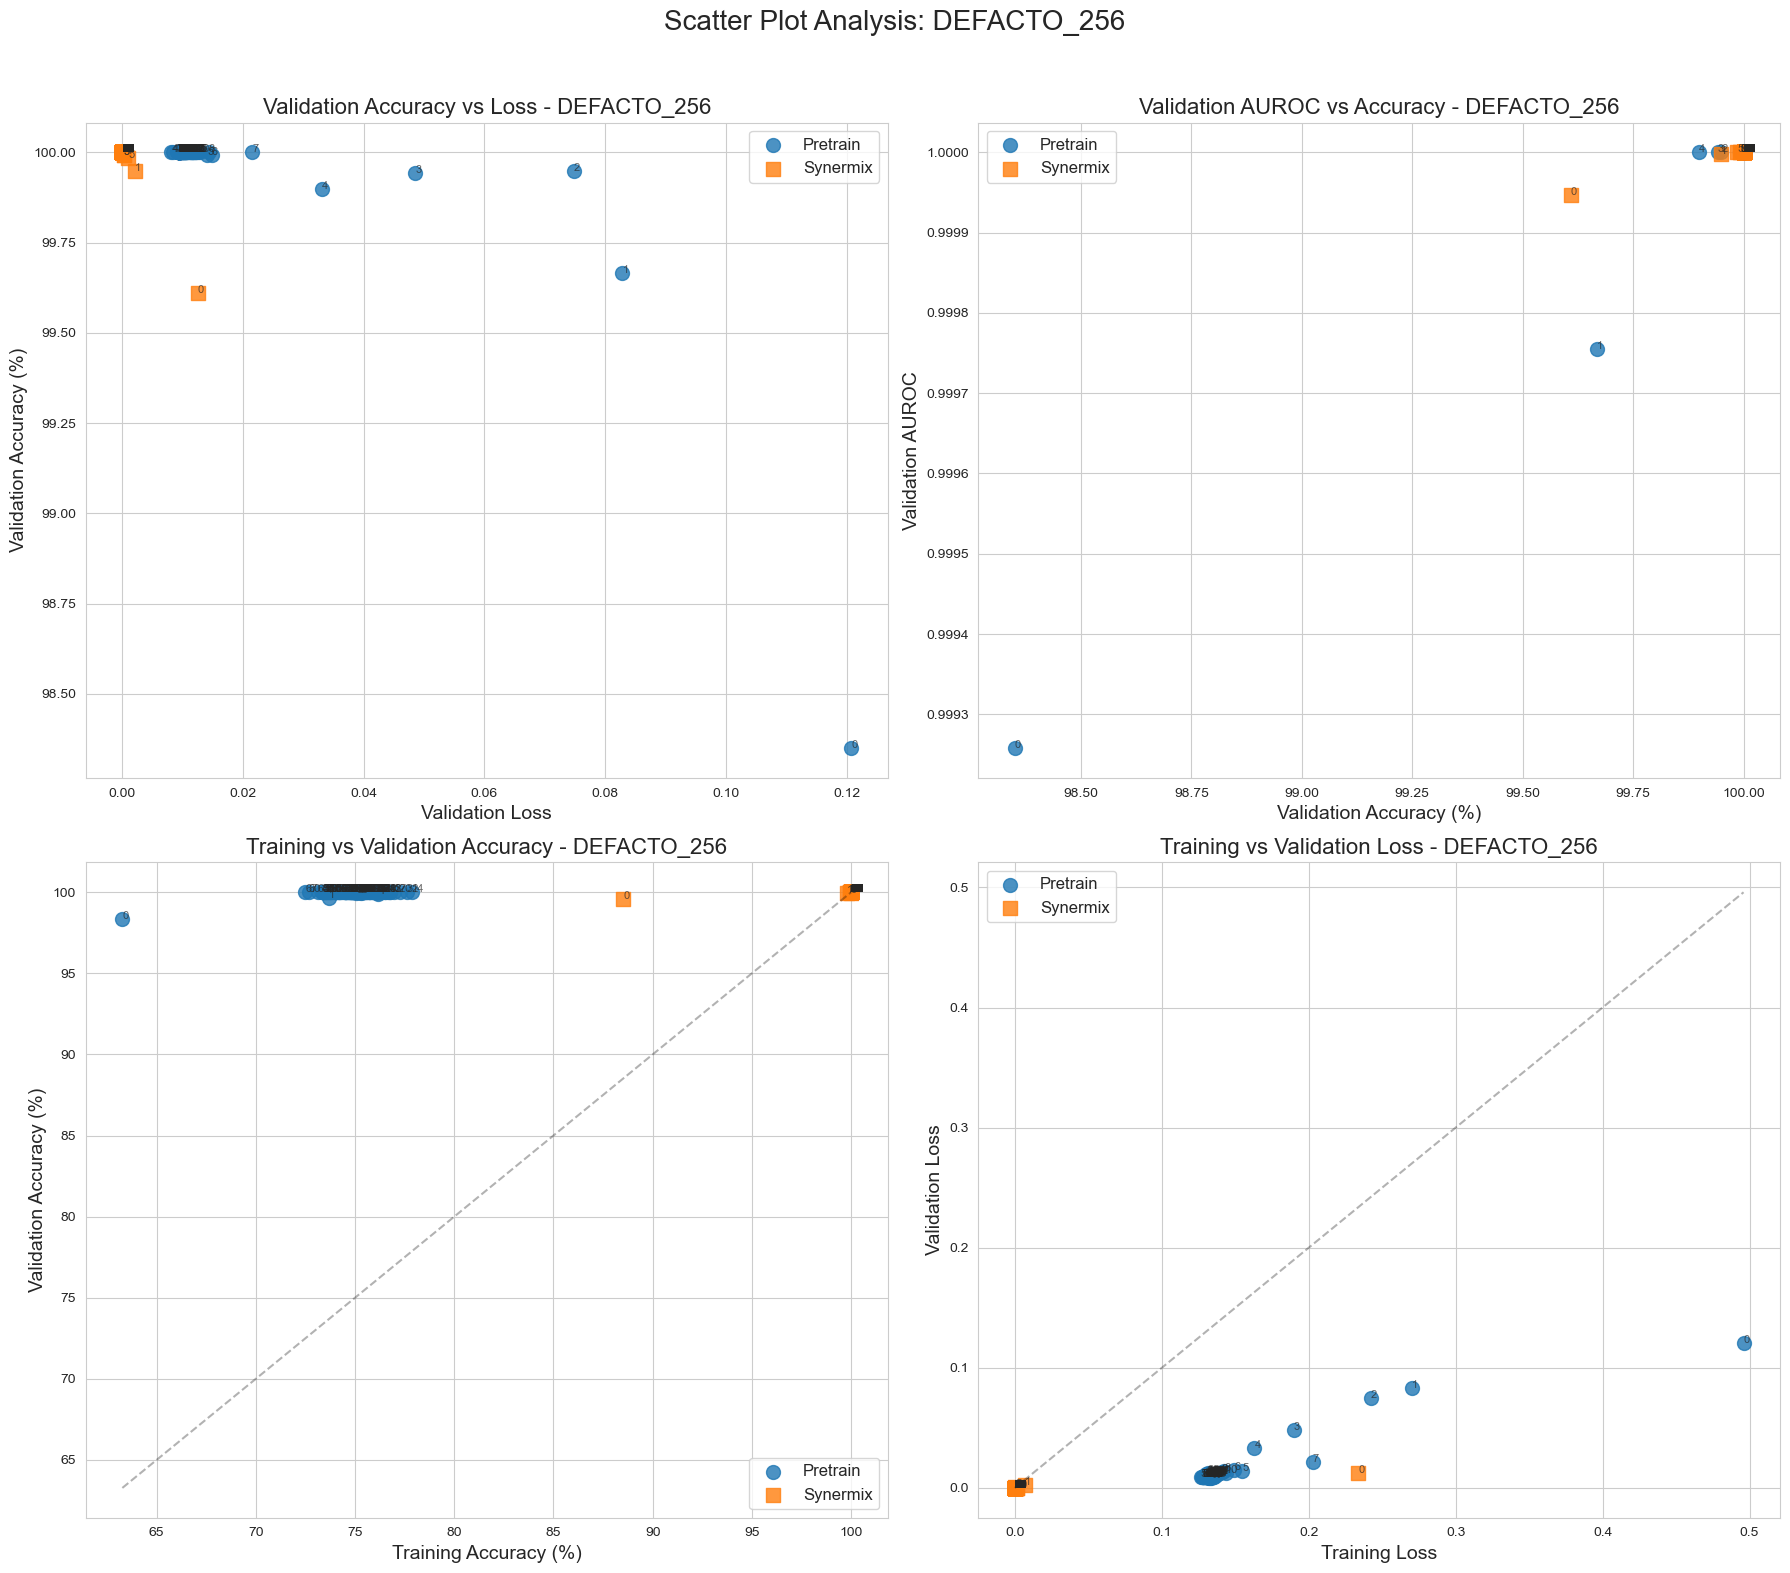

Creating scatter plots for FLUX1_256


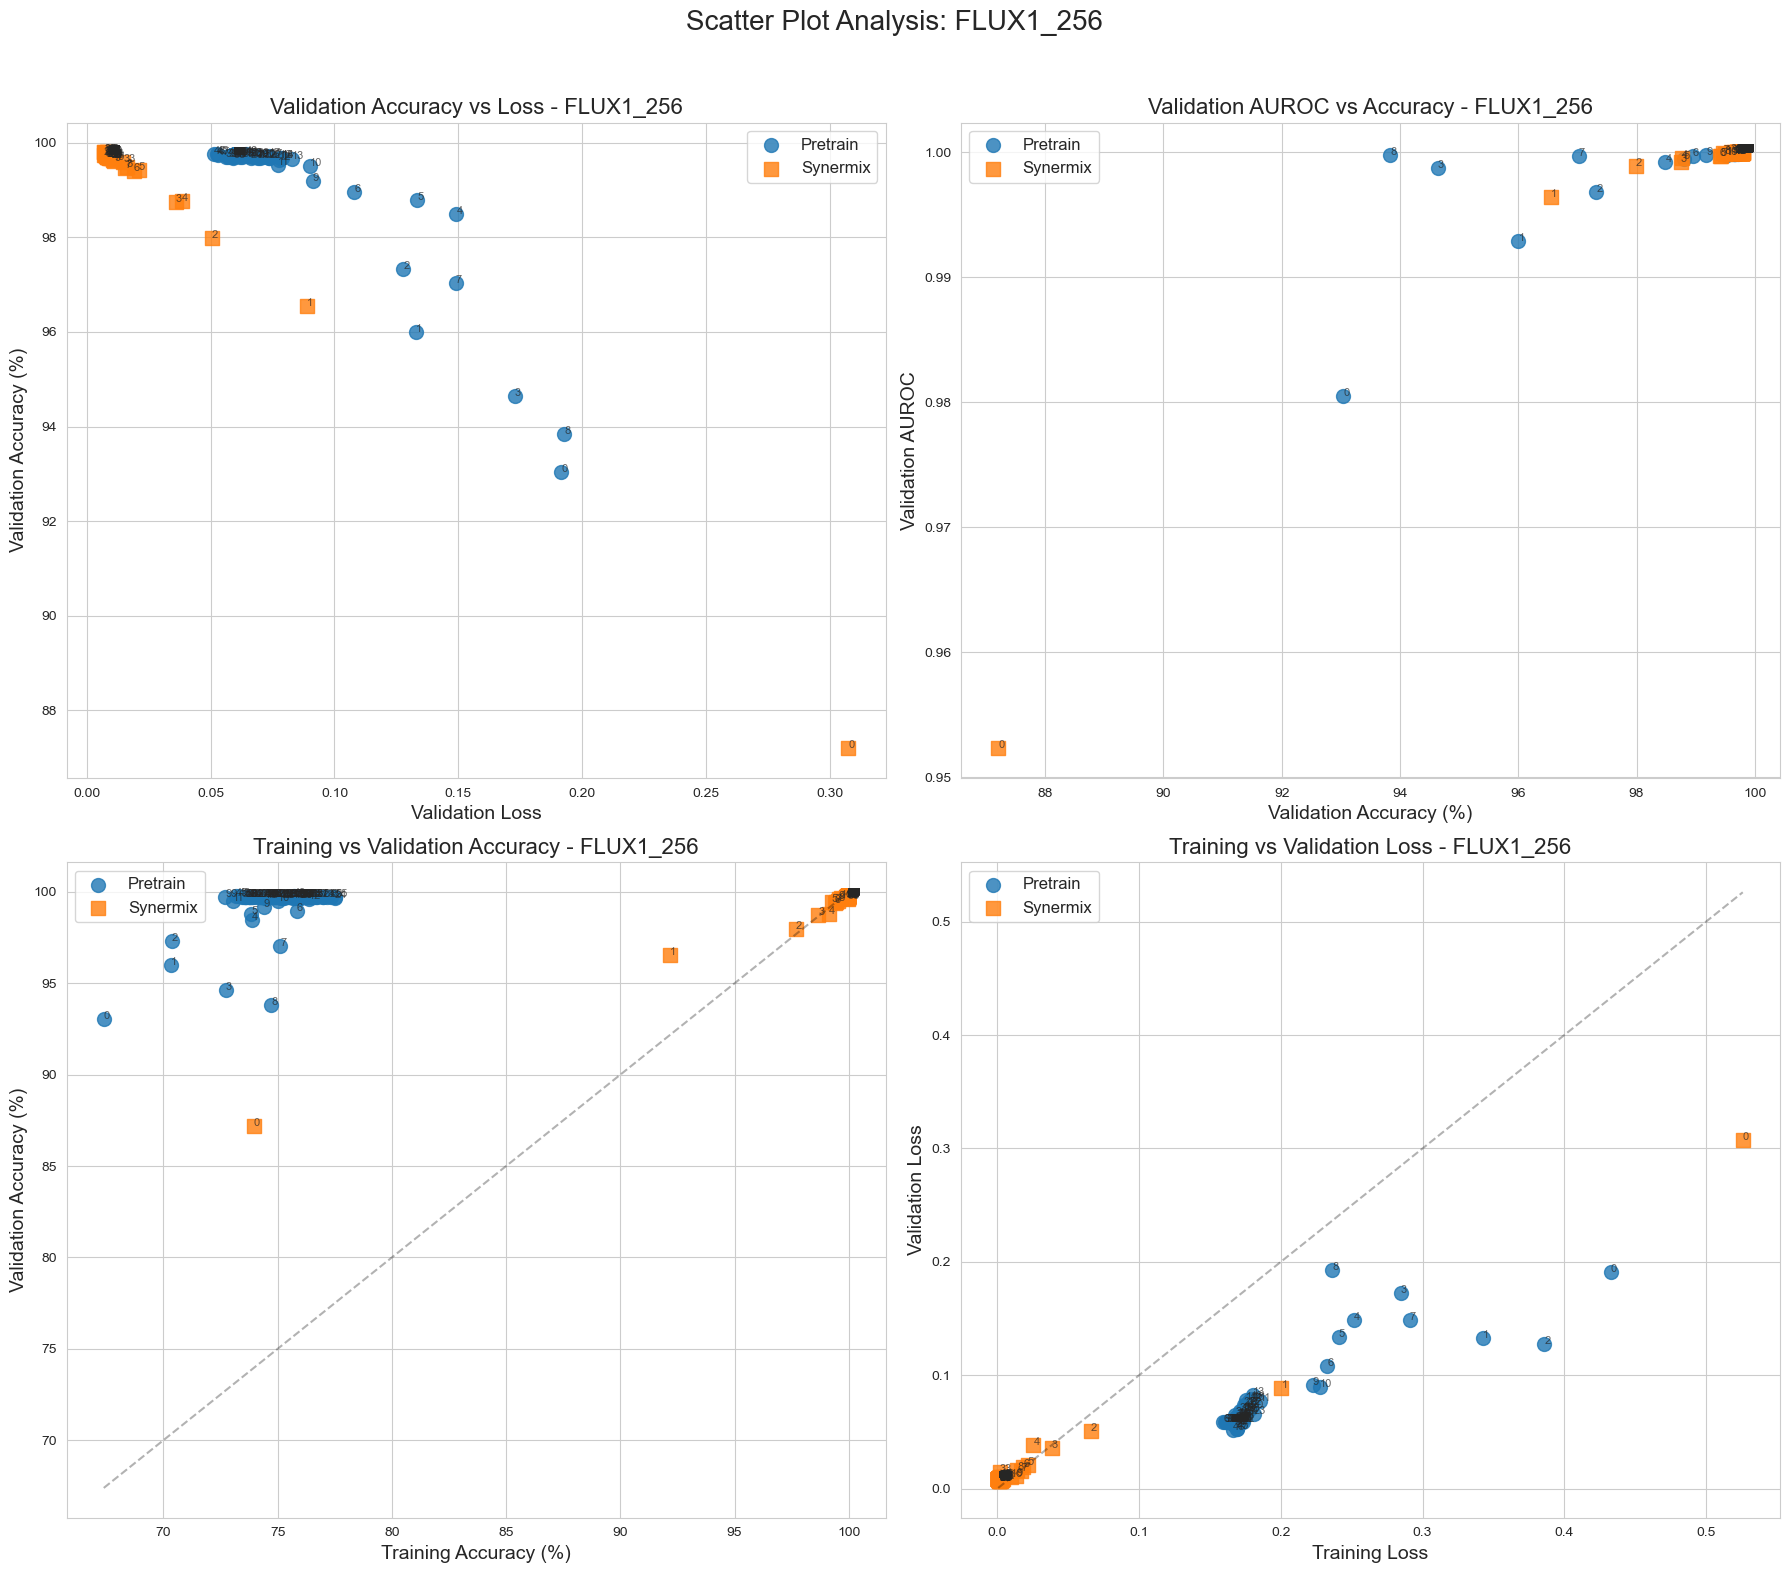

Creating scatter plots for StableDiffusion_256


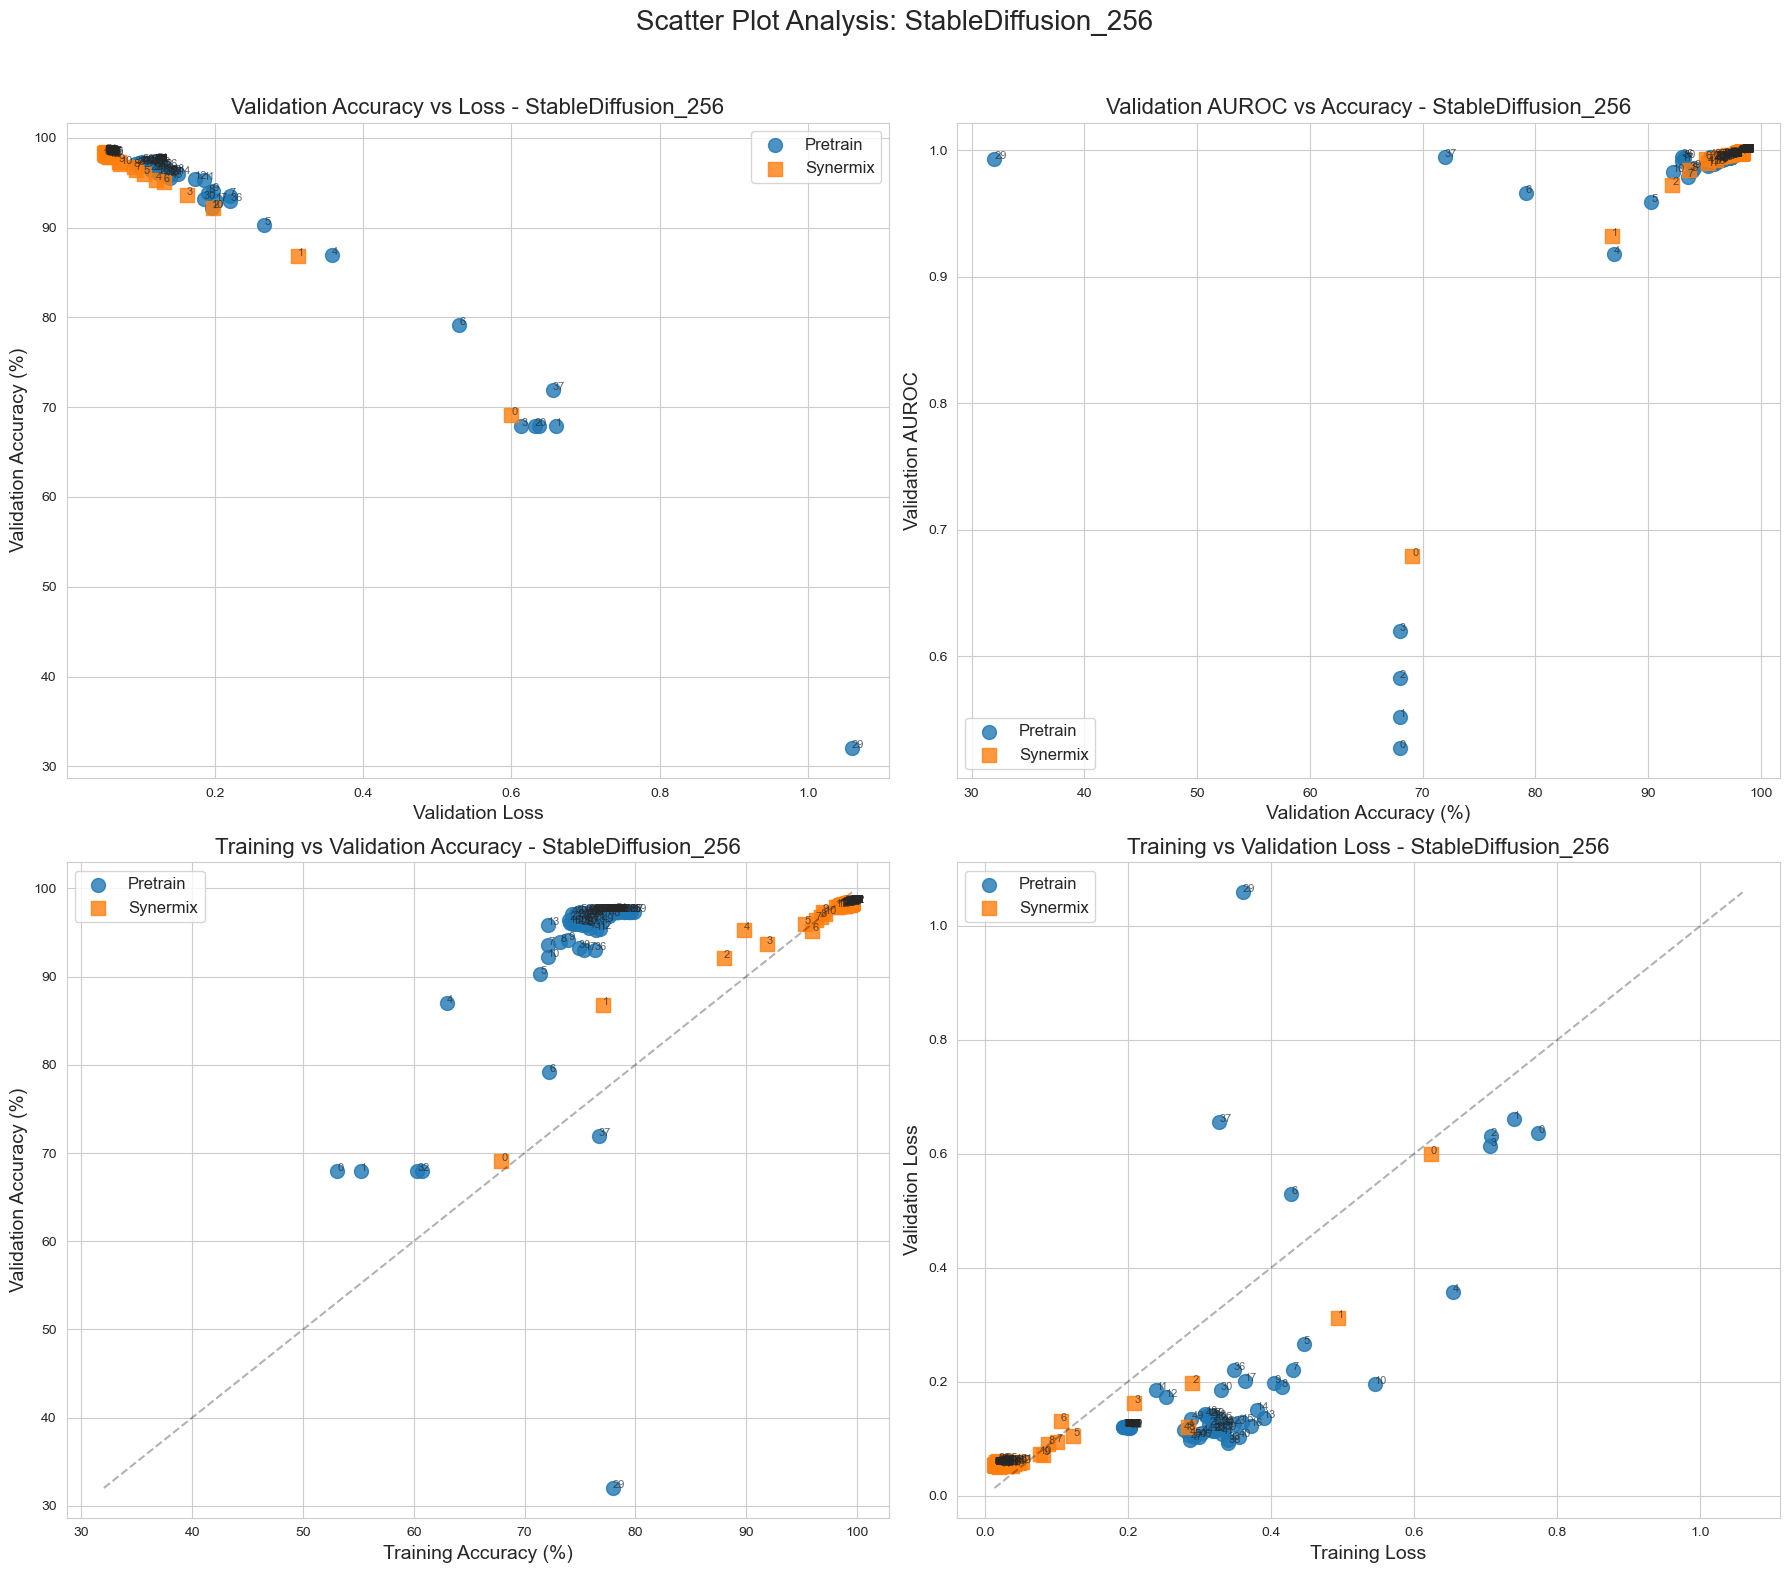

Creating scatter plots for StyleGAN2_256


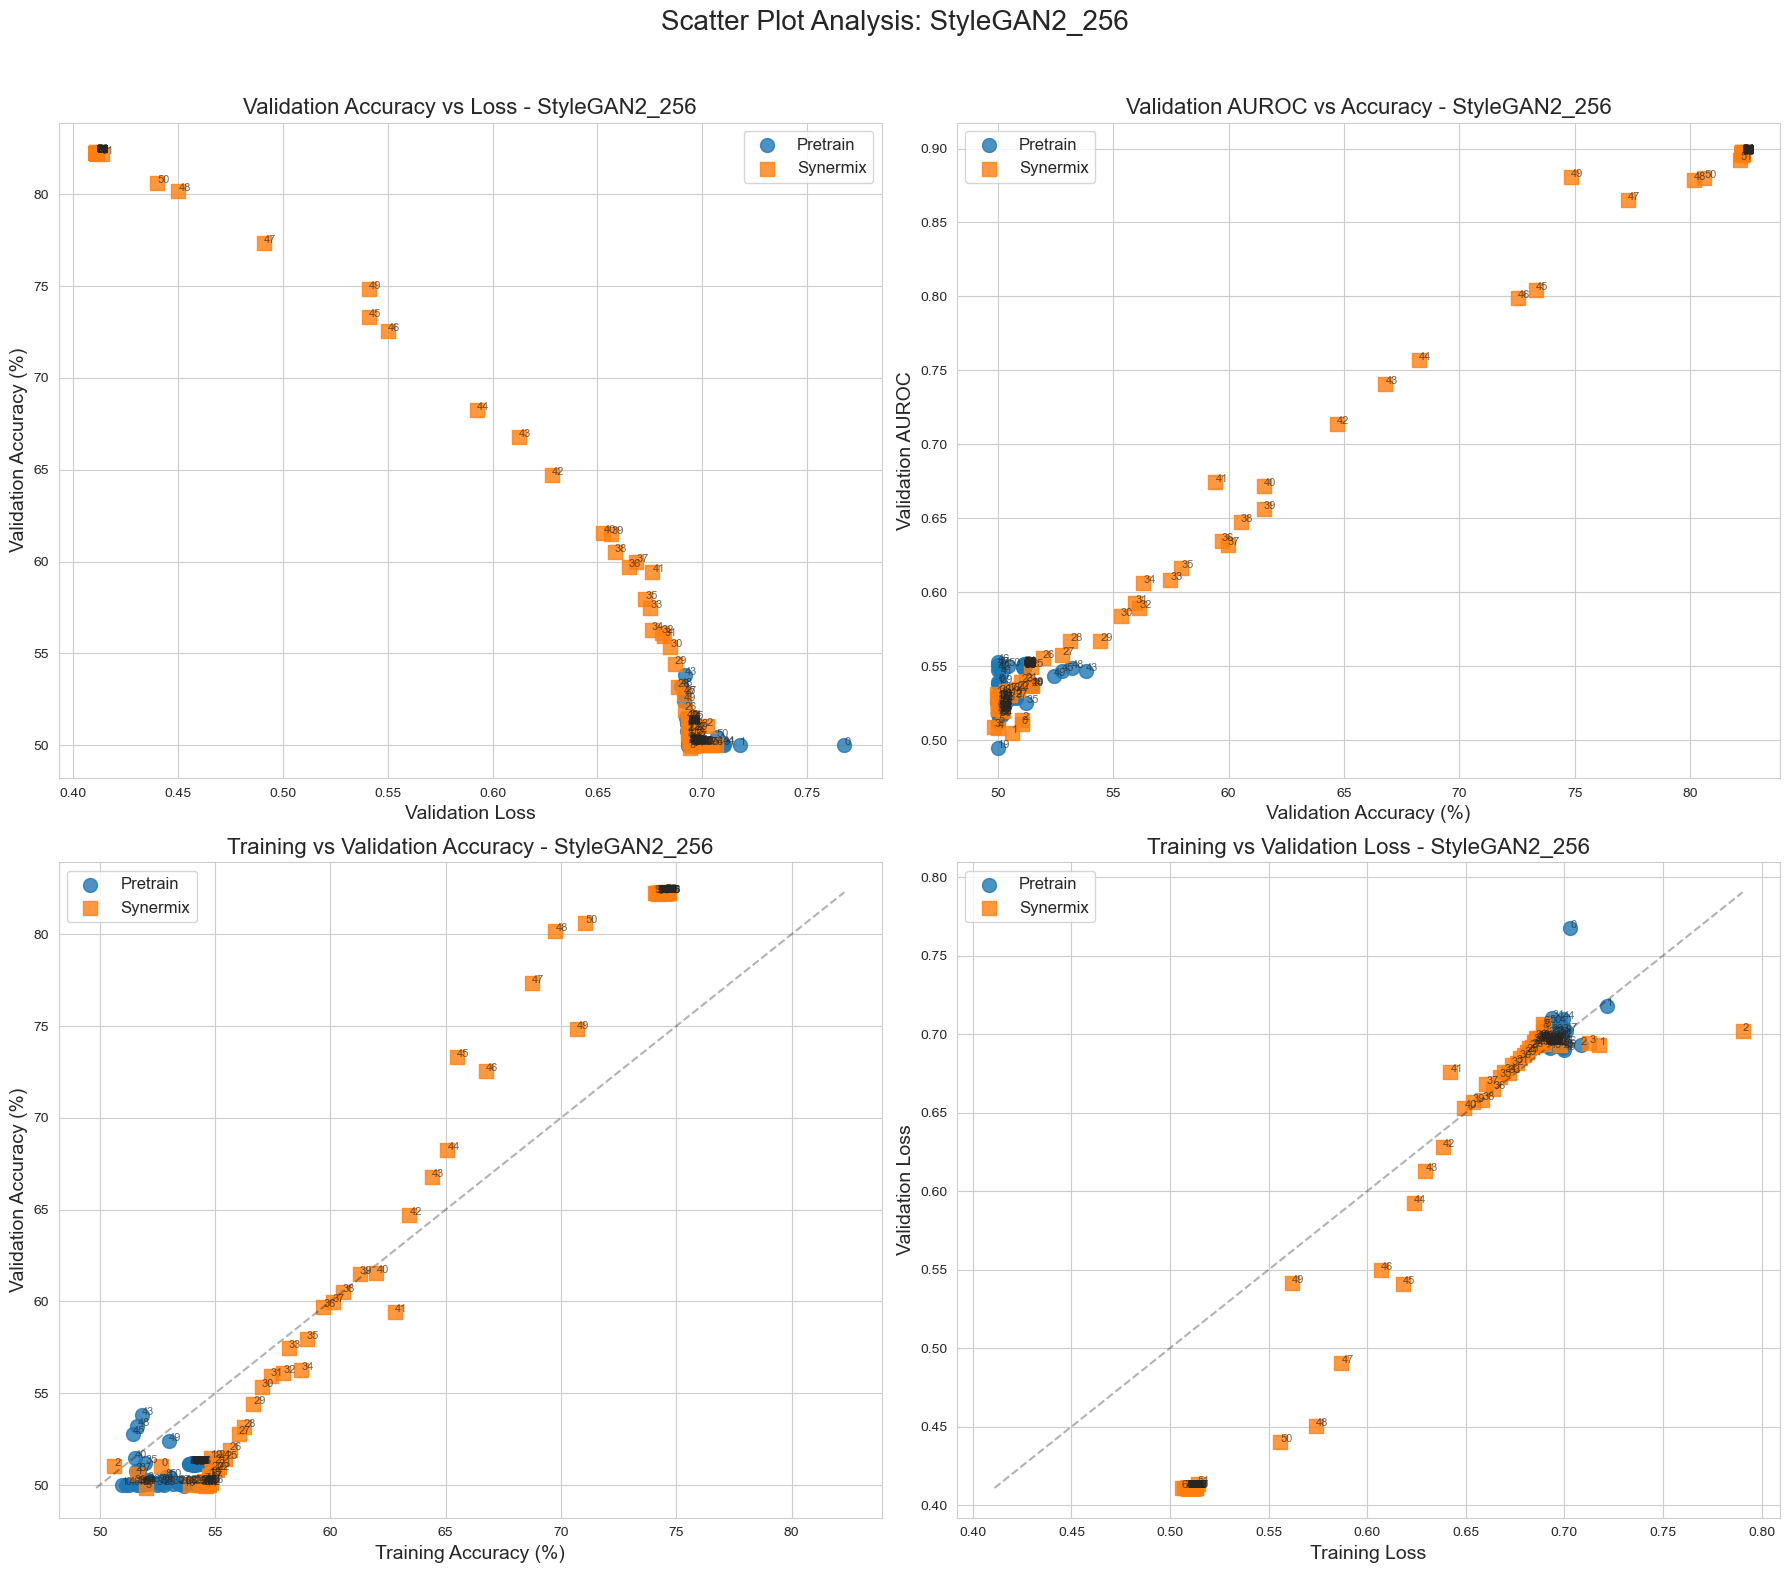

Creating scatter plots for StyleGAN_256


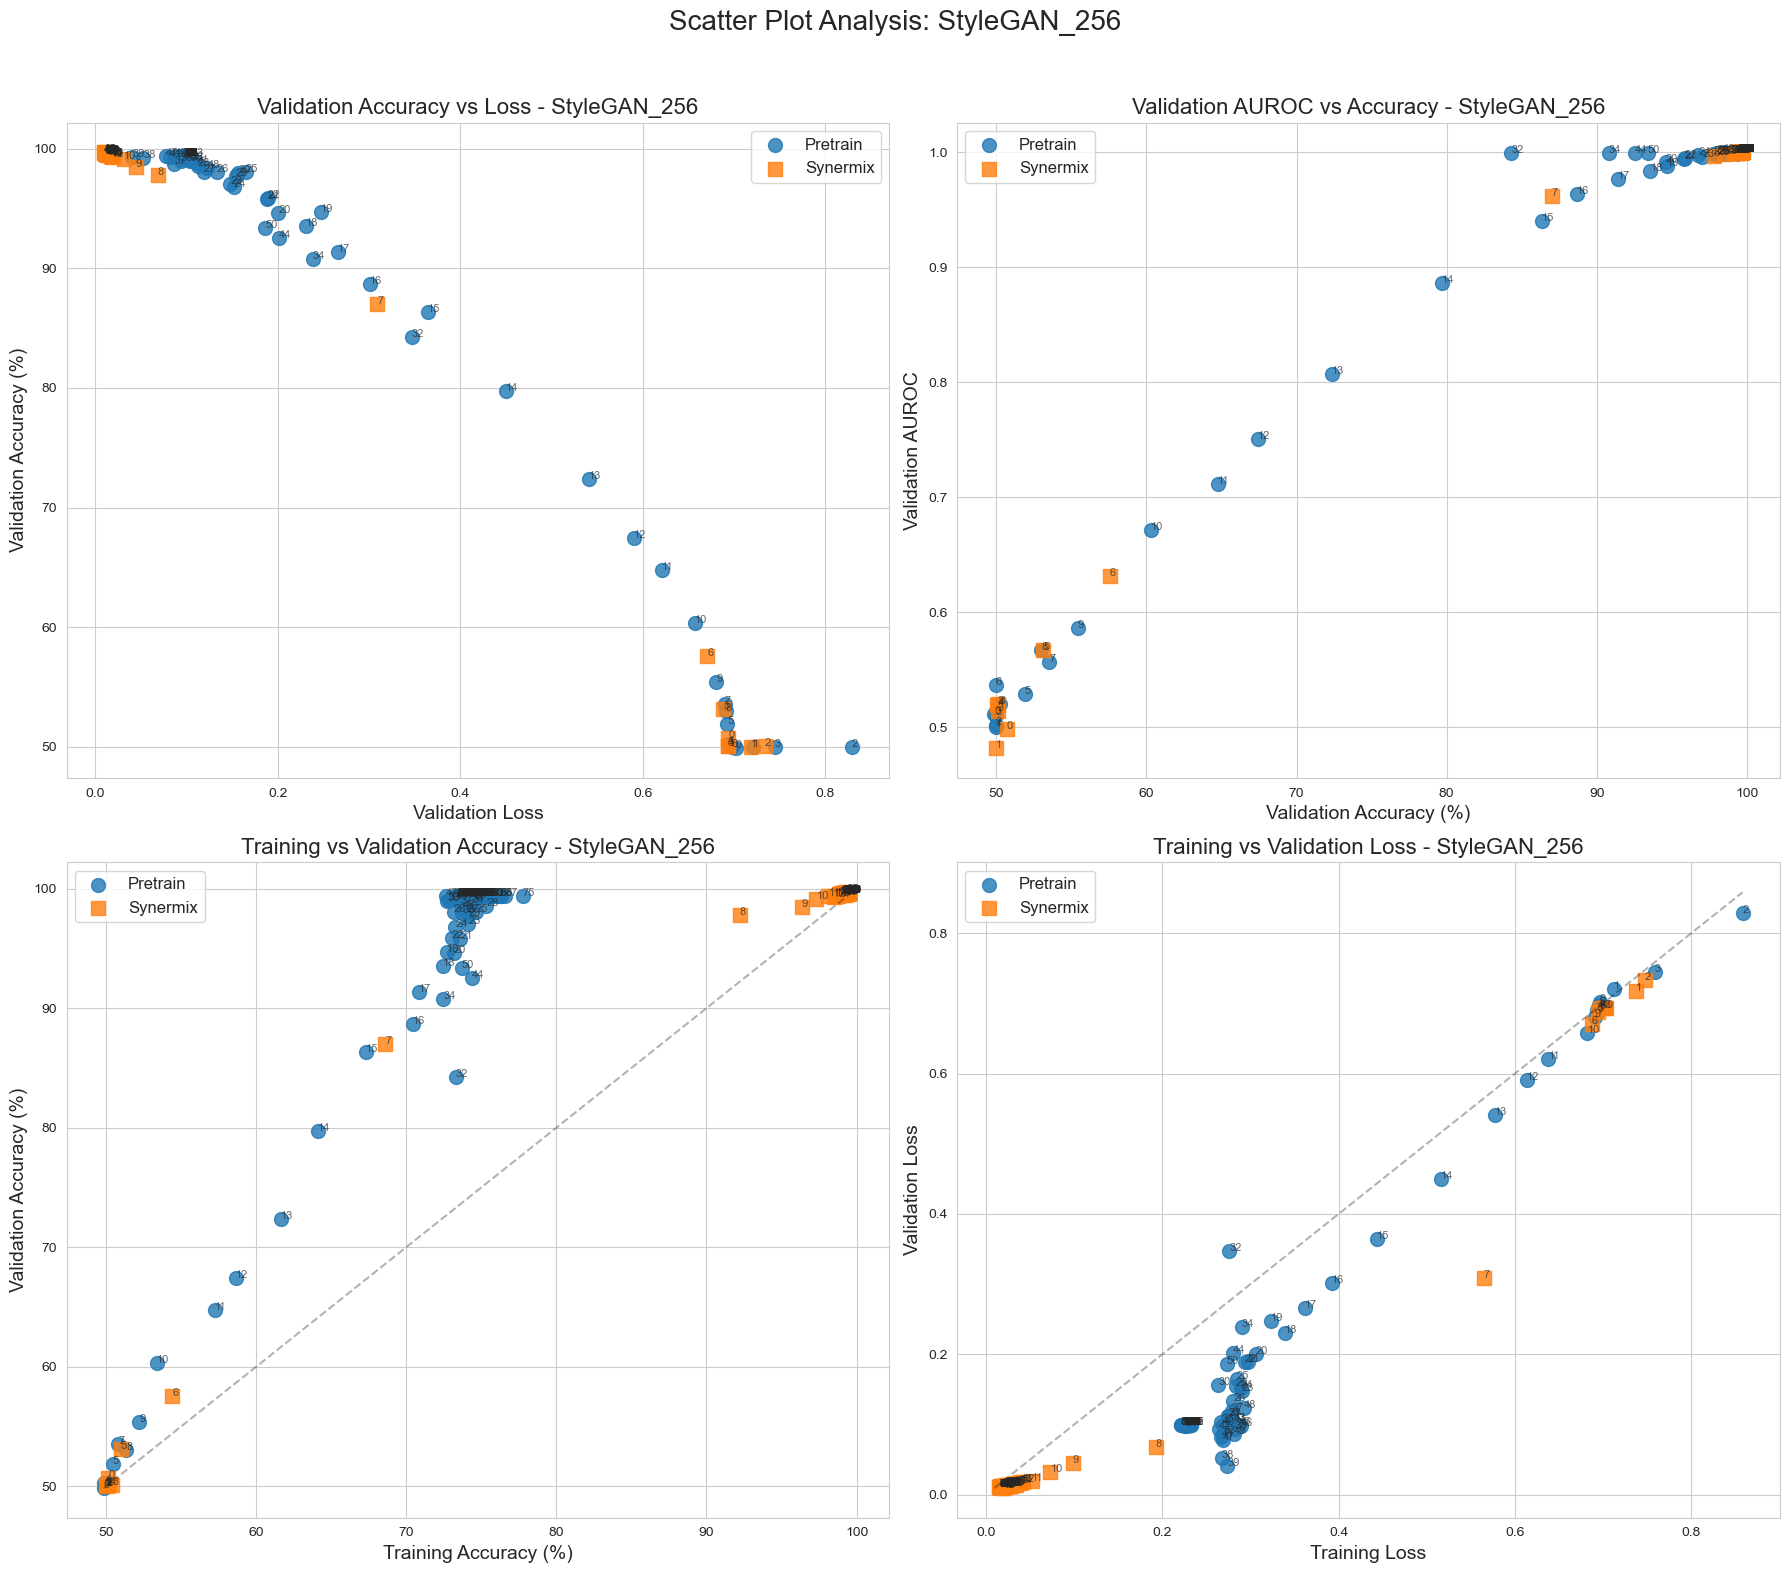

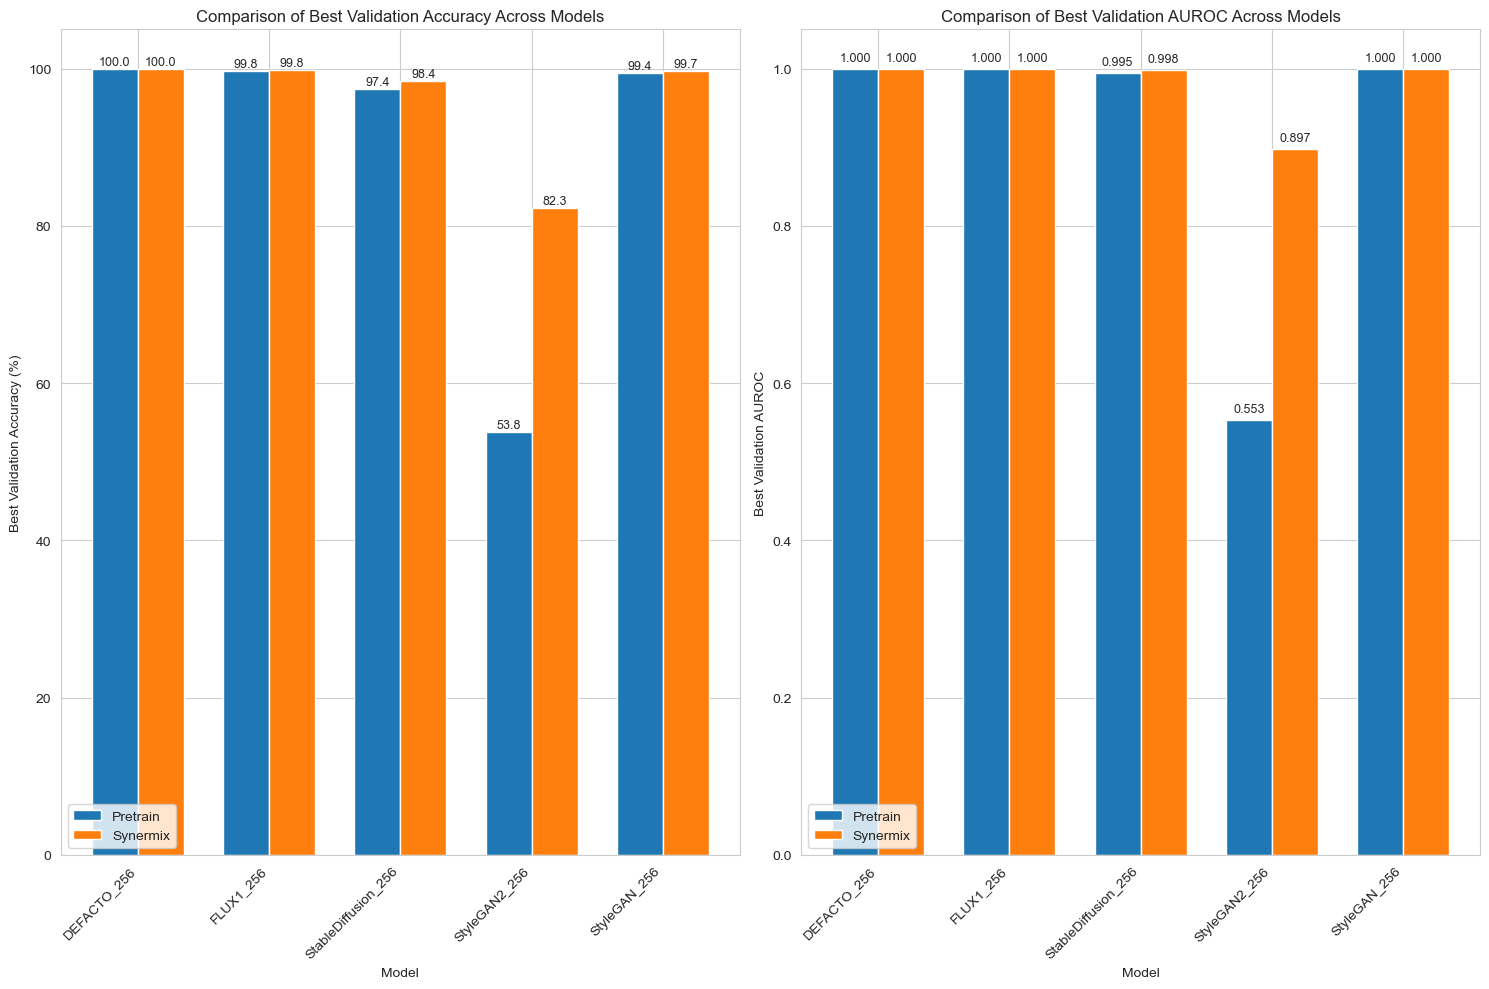

In [3]:
# Create scatter plot visualizations for each model
plt.figure(figsize=(20, 15))

# Store data for final comparison
all_model_data = {}

# Process each model
for i, model_name in enumerate(models):
    # Load data
    pretrain_df, synermix_df = load_model_data(model_name)
    if pretrain_df is None or synermix_df is None:
        continue
        
    print(f"Creating scatter plots for {model_name}")
    all_model_data[model_name] = {'pretrain': pretrain_df, 'synermix': synermix_df}
    
    # Create a figure with subplots for this model
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    
    # 1. Accuracy vs Loss (Validation)
    axes[0, 0].scatter(pretrain_df['Valid Loss'], pretrain_df['Valid Acc.'], 
                     label='Pretrain', alpha=0.8, s=100, marker='o')
    axes[0, 0].scatter(synermix_df['Valid Loss'], synermix_df['Valid Acc.'], 
                     label='Synermix', alpha=0.8, s=100, marker='s')
    axes[0, 0].set_title(f'Validation Accuracy vs Loss - {model_name}', fontsize=16)
    axes[0, 0].set_xlabel('Validation Loss', fontsize=14)
    axes[0, 0].set_ylabel('Validation Accuracy (%)', fontsize=14)
    
    # Add epoch labels to points
    for j, txt in enumerate(pretrain_df.index):
        axes[0, 0].annotate(j, (pretrain_df['Valid Loss'].iloc[j], pretrain_df['Valid Acc.'].iloc[j]),
                          fontsize=8, alpha=0.7)
    for j, txt in enumerate(synermix_df.index):
        axes[0, 0].annotate(j, (synermix_df['Valid Loss'].iloc[j], synermix_df['Valid Acc.'].iloc[j]),
                          fontsize=8, alpha=0.7)
    axes[0, 0].legend(fontsize=12)
    
    # 2. AUROC vs Accuracy (Validation)
    axes[0, 1].scatter(pretrain_df['Valid Acc.'], pretrain_df['Valid AUROC.'], 
                     label='Pretrain', alpha=0.8, s=100, marker='o')
    axes[0, 1].scatter(synermix_df['Valid Acc.'], synermix_df['Valid AUROC.'], 
                     label='Synermix', alpha=0.8, s=100, marker='s')
    axes[0, 1].set_title(f'Validation AUROC vs Accuracy - {model_name}', fontsize=16)
    axes[0, 1].set_xlabel('Validation Accuracy (%)', fontsize=14)
    axes[0, 1].set_ylabel('Validation AUROC', fontsize=14)
    
    # Add epoch labels
    for j, txt in enumerate(pretrain_df.index):
        axes[0, 1].annotate(j, (pretrain_df['Valid Acc.'].iloc[j], pretrain_df['Valid AUROC.'].iloc[j]),
                          fontsize=8, alpha=0.7)
    for j, txt in enumerate(synermix_df.index):
        axes[0, 1].annotate(j, (synermix_df['Valid Acc.'].iloc[j], synermix_df['Valid AUROC.'].iloc[j]),
                          fontsize=8, alpha=0.7)
    axes[0, 1].legend(fontsize=12)
    
    # 3. Training vs Validation Accuracy
    axes[1, 0].scatter(pretrain_df['Train Acc.'], pretrain_df['Valid Acc.'], 
                     label='Pretrain', alpha=0.8, s=100, marker='o')
    axes[1, 0].scatter(synermix_df['Train Acc.'], synermix_df['Valid Acc.'], 
                     label='Synermix', alpha=0.8, s=100, marker='s')
    axes[1, 0].set_title(f'Training vs Validation Accuracy - {model_name}', fontsize=16)
    axes[1, 0].set_xlabel('Training Accuracy (%)', fontsize=14)
    axes[1, 0].set_ylabel('Validation Accuracy (%)', fontsize=14)
    
    # Add epoch labels
    for j, txt in enumerate(pretrain_df.index):
        axes[1, 0].annotate(j, (pretrain_df['Train Acc.'].iloc[j], pretrain_df['Valid Acc.'].iloc[j]),
                          fontsize=8, alpha=0.7)
    for j, txt in enumerate(synermix_df.index):
        axes[1, 0].annotate(j, (synermix_df['Train Acc.'].iloc[j], synermix_df['Valid Acc.'].iloc[j]),
                          fontsize=8, alpha=0.7)
    axes[1, 0].legend(fontsize=12)
    
    # 4. Training vs Validation Loss
    axes[1, 1].scatter(pretrain_df['Train Loss'], pretrain_df['Valid Loss'], 
                     label='Pretrain', alpha=0.8, s=100, marker='o')
    axes[1, 1].scatter(synermix_df['Train Loss'], synermix_df['Valid Loss'], 
                     label='Synermix', alpha=0.8, s=100, marker='s')
    axes[1, 1].set_title(f'Training vs Validation Loss - {model_name}', fontsize=16)
    axes[1, 1].set_xlabel('Training Loss', fontsize=14)
    axes[1, 1].set_ylabel('Validation Loss', fontsize=14)
    
    # Add epoch labels
    for j, txt in enumerate(pretrain_df.index):
        axes[1, 1].annotate(j, (pretrain_df['Train Loss'].iloc[j], pretrain_df['Valid Loss'].iloc[j]),
                          fontsize=8, alpha=0.7)
    for j, txt in enumerate(synermix_df.index):
        axes[1, 1].annotate(j, (synermix_df['Train Loss'].iloc[j], synermix_df['Valid Loss'].iloc[j]),
                          fontsize=8, alpha=0.7)
    axes[1, 1].legend(fontsize=12)
    
    # Add a diagonal line for reference in Training vs Validation plots
    min_acc = min(pretrain_df['Train Acc.'].min(), synermix_df['Train Acc.'].min(), 
                  pretrain_df['Valid Acc.'].min(), synermix_df['Valid Acc.'].min())
    max_acc = max(pretrain_df['Train Acc.'].max(), synermix_df['Train Acc.'].max(), 
                  pretrain_df['Valid Acc.'].max(), synermix_df['Valid Acc.'].max())
    axes[1, 0].plot([min_acc, max_acc], [min_acc, max_acc], 'k--', alpha=0.3)
    
    min_loss = min(pretrain_df['Train Loss'].min(), synermix_df['Train Loss'].min(), 
                   pretrain_df['Valid Loss'].min(), synermix_df['Valid Loss'].min())
    max_loss = max(pretrain_df['Train Loss'].max(), synermix_df['Train Loss'].max(), 
                   pretrain_df['Valid Loss'].max(), synermix_df['Valid Loss'].max())
    axes[1, 1].plot([min_loss, max_loss], [min_loss, max_loss], 'k--', alpha=0.3)
    
    # Add a main title
    fig.suptitle(f'Scatter Plot Analysis: {model_name}', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Create a final comparison plot of best validation accuracy across all models
plt.figure(figsize=(15, 10))
bar_width = 0.35
index = np.arange(len(models))

pretrain_best_acc = []
synermix_best_acc = []
pretrain_best_auroc = []
synermix_best_auroc = []

for model_name in models:
    if model_name in all_model_data:
        pretrain_df = all_model_data[model_name]['pretrain']
        synermix_df = all_model_data[model_name]['synermix']
        
        pretrain_best_acc.append(pretrain_df['Valid Acc.'].max())
        synermix_best_acc.append(synermix_df['Valid Acc.'].max())
        pretrain_best_auroc.append(pretrain_df['Valid AUROC.'].max())
        synermix_best_auroc.append(synermix_df['Valid AUROC.'].max())
    else:
        pretrain_best_acc.append(0)
        synermix_best_acc.append(0)
        pretrain_best_auroc.append(0)
        synermix_best_auroc.append(0)

# Plot best validation accuracy for each model
plt.subplot(1, 2, 1)
bar1 = plt.bar(index - bar_width/2, pretrain_best_acc, bar_width, label='Pretrain')
bar2 = plt.bar(index + bar_width/2, synermix_best_acc, bar_width, label='Synermix')

plt.xlabel('Model')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Comparison of Best Validation Accuracy Across Models')
plt.xticks(index, models, rotation=45, ha='right')
plt.legend()

# Add value labels on top of bars
for i, v in enumerate(pretrain_best_acc):
    plt.text(i - bar_width/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)
    
for i, v in enumerate(synermix_best_acc):
    plt.text(i + bar_width/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

# Plot best validation AUROC for each model
plt.subplot(1, 2, 2)
bar1 = plt.bar(index - bar_width/2, pretrain_best_auroc, bar_width, label='Pretrain')
bar2 = plt.bar(index + bar_width/2, synermix_best_auroc, bar_width, label='Synermix')

plt.xlabel('Model')
plt.ylabel('Best Validation AUROC')
plt.title('Comparison of Best Validation AUROC Across Models')
plt.xticks(index, models, rotation=45, ha='right')
plt.legend()

# Add value labels on top of bars
for i, v in enumerate(pretrain_best_auroc):
    plt.text(i - bar_width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    
for i, v in enumerate(synermix_best_auroc):
    plt.text(i + bar_width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()